# Analisis Exploratorio de Datos (EDA) Completo
## Motor de Recomendacion Turistica TUI - TFM UCM 2025

Este notebook realiza un analisis exhaustivo de la calidad de todos los datos del proyecto:

1. **Calidad de datos**: Valores nulos, duplicados e inconsistencias
2. **Distribuciones y variables relevantes**
3. **Patrones, outliers y relaciones entre variables**
4. **Visualizaciones**: Media, mediana, propuestas para sustituir valores o descartar registros

### Fuentes de datos analizadas:

| Fuente | Tipo | Descripcion |
|--------|------|-------------|
| Base de datos SQLite | BD | Resenas, clima, indicadores, destinos, paquetes, usuarios, interacciones |
| clima_todos_los_destinos.csv | CSV | Datos climaticos historicos |
| conectividad_y_pasajeros_2025.csv | CSV | Conectividad aerea y pasajeros |
| seguridad_y_sanidad_banco_mundial.csv | CSV | Indicadores de seguridad y sanidad |

In [20]:
#ho 
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
''' 
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Rutas
BASE_DIR = Path(r'/Users/gioiasacco/tfm')
DB_PATH = BASE_DIR / '/Users/gioiasacco/Desktop/TrabajoFinalUCM/TFM/data'
CSV_CLIMA = BASE_DIR / 'data' / 'clima_todos_los_destinos.csv'
CSV_CONECTIVIDAD = BASE_DIR / 'data' / 'conectividad_y_pasajeros_2025.csv'
CSV_SEGURIDAD = BASE_DIR / 'data' / 'seguridad_y_sanidad_banco_mundial.csv'

# Funcion auxiliar para consultas
def query(sql, db=DB_PATH):
    conn = sqlite3.connect(str(db))
    df = pd.read_sql_query(sql, conn)
    conn.close()
    return df

def get_tables():
    return query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")

print(f'Base de datos: {DB_PATH} ({DB_PATH.stat().st_size / (1024*1024):.1f} MB)')
print(f'Tablas disponibles:')
tables = get_tables()
for _, row in tables.iterrows():
    n = query(f"SELECT COUNT(*) as n FROM [{row['name']}]")['n'].iloc[0]
    print(f'  - {row["name"]}: {n:,} registros')

'''

' \nwarnings.filterwarnings(\'ignore\')\nsns.set_theme(style=\'whitegrid\', palette=\'husl\')\nplt.rcParams[\'figure.figsize\'] = (14, 6)\nplt.rcParams[\'figure.dpi\'] = 100\nplt.rcParams[\'font.size\'] = 10\n\n# Rutas\nBASE_DIR = Path(r\'/Users/gioiasacco/tfm\')\nDB_PATH = BASE_DIR / \'/Users/gioiasacco/Desktop/TrabajoFinalUCM/TFM/data\'\nCSV_CLIMA = BASE_DIR / \'data\' / \'clima_todos_los_destinos.csv\'\nCSV_CONECTIVIDAD = BASE_DIR / \'data\' / \'conectividad_y_pasajeros_2025.csv\'\nCSV_SEGURIDAD = BASE_DIR / \'data\' / \'seguridad_y_sanidad_banco_mundial.csv\'\n\n# Funcion auxiliar para consultas\ndef query(sql, db=DB_PATH):\n    conn = sqlite3.connect(str(db))\n    df = pd.read_sql_query(sql, conn)\n    conn.close()\n    return df\n\ndef get_tables():\n    return query("SELECT name FROM sqlite_master WHERE type=\'table\' ORDER BY name")\n\nprint(f\'Base de datos: {DB_PATH} ({DB_PATH.stat().st_size / (1024*1024):.1f} MB)\')\nprint(f\'Tablas disponibles:\')\ntables = get_tables()\nfo

In [21]:
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10


# ============================================================
# RUTAS
# ============================================================

BASE_DIR = Path('/Users/gioiasacco/Desktop/TrabajoFinalUCM/TFM')
DATA_DIR = BASE_DIR / 'data'

DB_PATH = DATA_DIR / 'tui_recomendador.db'

CSV_CLIMA = DATA_DIR / 'clima_todos_los_destinos.csv'
CSV_CONECTIVIDAD = DATA_DIR / 'conectividad_y_pasajeros_2025.csv'
CSV_SEGURIDAD = DATA_DIR / 'seguridad_y_sanidad_banco_mundial.csv'


# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def query(sql, db=DB_PATH):
    """
    Ejecuta una consulta SQL sobre la base de datos SQLite
    y devuelve el resultado como DataFrame.
    """
    with sqlite3.connect(str(db)) as conn:
        return pd.read_sql_query(sql, conn)


def get_tables():
    """
    Devuelve las tablas disponibles en la base de datos.
    """
    return query(
        """
        SELECT name
        FROM sqlite_master
        WHERE type='table'
        ORDER BY name
        """
    )


# ============================================================
# COMPROBACIÓN DE ARCHIVOS
# ============================================================

archivos = {
    'Base de datos': DB_PATH,
    'Clima': CSV_CLIMA,
    'Conectividad': CSV_CONECTIVIDAD,
    'Seguridad y sanidad': CSV_SEGURIDAD
}

print('COMPROBACIÓN DE ARCHIVOS')
print('-' * 50)

for nombre, ruta in archivos.items():
    estado = 'OK' if ruta.exists() else 'NO ENCONTRADO'
    print(f'{nombre}: {estado}')
    print(f'  {ruta}')


# ============================================================
# INFORMACIÓN DE LA BASE DE DATOS
# ============================================================

print('\n' + '=' * 60)
print('BASE DE DATOS')
print('=' * 60)

print(
    f'Base de datos: {DB_PATH}\n'
    f'Tamaño: {DB_PATH.stat().st_size / (1024 * 1024):.1f} MB'
)

print('\nTablas disponibles:')

tables = get_tables()

for _, row in tables.iterrows():

    tabla = row['name']

    n = query(
        f'SELECT COUNT(*) AS n FROM [{tabla}]'
    )['n'].iloc[0]

    print(f'  - {tabla}: {n:,} registros')

COMPROBACIÓN DE ARCHIVOS
--------------------------------------------------
Base de datos: OK
  /Users/gioiasacco/Desktop/TrabajoFinalUCM/TFM/data/tui_recomendador.db
Clima: OK
  /Users/gioiasacco/Desktop/TrabajoFinalUCM/TFM/data/clima_todos_los_destinos.csv
Conectividad: OK
  /Users/gioiasacco/Desktop/TrabajoFinalUCM/TFM/data/conectividad_y_pasajeros_2025.csv
Seguridad y sanidad: OK
  /Users/gioiasacco/Desktop/TrabajoFinalUCM/TFM/data/seguridad_y_sanidad_banco_mundial.csv

BASE DE DATOS
Base de datos: /Users/gioiasacco/Desktop/TrabajoFinalUCM/TFM/data/tui_recomendador.db
Tamaño: 55.9 MB

Tablas disponibles:
  - clima_destinos: 1,638 registros
  - conectividad_destinos: 39 registros
  - customer_bookings: 149,941 registros
  - destinos_caracteristicas: 39 registros
  - embeddings_meta: 0 registros
  - experiencias: 5,850 registros
  - experiencias_reales: 0 registros
  - indicadores_destino: 3,342 registros
  - interacciones: 0 registros
  - paquetes: 0 registros
  - paquetes_versiones

---
## 1. CALIDAD DE DATOS: Valores Nulos, Duplicados e Inconsistencias



Reseñas

In [19]:
# Cargamos la tabla de resenas
df_resenas = query("SELECT * FROM resenas")
print(f'Total registros: {len(df_resenas):,}')
print(f'Columnas: {list(df_resenas.columns)}')
print(f'\n--- Tipos de datos ---')
print(df_resenas.dtypes)

# Valores nulos
print(f'\n--- Valores nulos por columna ---')
null_counts = df_resenas.isnull().sum()
null_pct = (null_counts / len(df_resenas) * 100).round(2)
null_df = pd.DataFrame({'Nulos': null_counts, 'Porcentaje (%)': null_pct})
null_df = null_df[null_df['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(null_df)

# Duplicados
dup_total = df_resenas.duplicated().sum()
print(f'\n--- Duplicados exactos: {dup_total} ({dup_total/len(df_resenas)*100:.2f}%) ---')

# Duplicados por texto
if 'texto_original' in df_resenas.columns:
    dup_texto = df_resenas['texto_original'].duplicated().sum()
    print(f'Textos duplicados: {dup_texto} ({dup_texto/len(df_resenas)*100:.2f}%)')

Total registros: 37,960
Columnas: ['id_resena', 'id_paquete', 'destino_nombre', 'fuente', 'texto_original', 'idioma', 'puntuacion', 'fecha_publicacion', 'url_fuente', 'fecha_extraccion']

--- Tipos de datos ---
id_resena            object
id_paquete           object
destino_nombre       object
fuente               object
texto_original       object
idioma               object
puntuacion           object
fecha_publicacion    object
url_fuente           object
fecha_extraccion     object
dtype: object

--- Valores nulos por columna ---
                   Nulos  Porcentaje (%)
id_paquete         37960          100.00
puntuacion         37960          100.00
fecha_publicacion  24354           64.16

--- Duplicados exactos: 0 (0.00%) ---
Textos duplicados: 0 (0.00%)


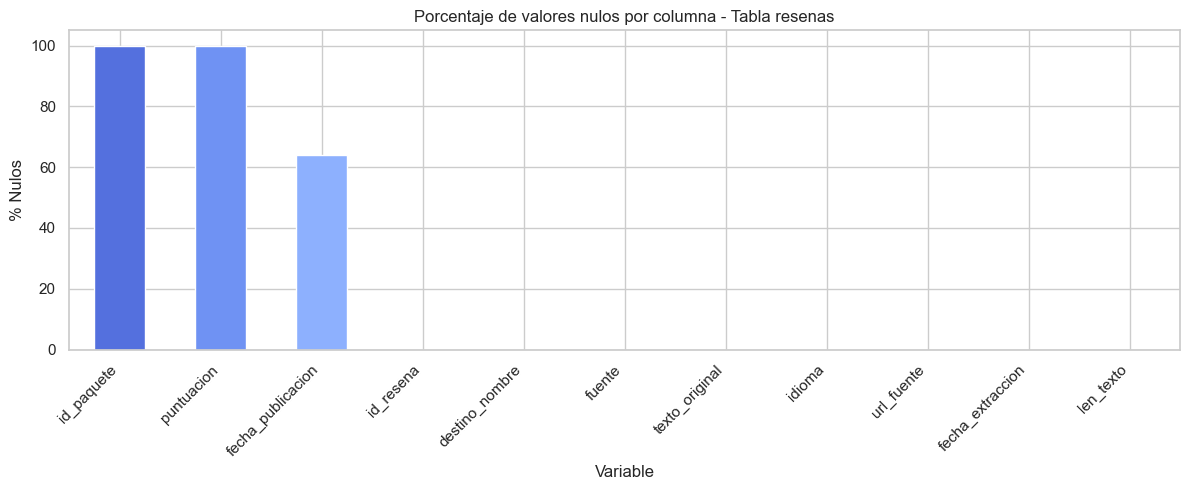


Interpretacion:
- id_paquete: ausencia estructural; no requiere imputacion para el analisis textual.
- puntuacion: no imputar. Las fuentes sin rating se analizaran mediante texto, sentimiento y embeddings.
- fecha_publicacion: mantener como dato ausente cuando no este disponible; no sustituir por fecha de extraccion.


In [ ]:
# Visualizacion: Porcentaje de nulos por columna en resenas

fig, ax = plt.subplots(figsize=(12, 5))

null_all = (
    df_resenas.isnull().sum() 
    / len(df_resenas) * 100
).sort_values(ascending=False)

null_all.plot(
    kind='bar',
    ax=ax,
    color=sns.color_palette('coolwarm', len(null_all))
)

ax.set_title('Porcentaje de valores nulos por columna - Tabla resenas')
ax.set_ylabel('% Nulos')
ax.set_xlabel('Variable')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


print('\nInterpretacion propuesta:')
print('- id_paquete: ausencia estructural; no requiere imputacion para el analisis textual.')
print('- puntuacion: no imputar. Las fuentes sin rating se analizaran mediante texto, sentimiento y embeddings.')
print('- fecha_publicacion: mantener como dato ausente cuando no este disponible; no sustituir por fecha de extraccion.')

explicacion: Los valores nulos se concentran en id_paquete, puntuacion y fecha_publicacion. Estas ausencias no impiden el análisis textual: no se imputarán las puntuaciones ni las fechas desconocidas, y las reseñas se utilizarán principalmente mediante análisis de sentimiento y embeddings.

Clima destinos 

In [41]:
df_clima_db = query("SELECT * FROM clima_destinos")
print(f'Total registros: {len(df_clima_db):,}')
print(f'Columnas: {list(df_clima_db.columns)}')

# Valores nulos
print(f'\n--- Valores nulos ---')
null_clima = df_clima_db.isnull().sum()
null_pct_clima = (null_clima / len(df_clima_db) * 100).round(2)
print(pd.DataFrame({'Nulos': null_clima, '%': null_pct_clima})[null_clima > 0])

# Duplicados
dup_clima = df_clima_db.duplicated().sum()
print(f'\nDuplicados exactos: {dup_clima}')

# Consistencia: rango de temperaturas
if 'temperatura_media' in df_clima_db.columns:
    temp_stats = df_clima_db['temperatura_media'].describe()
    print(f'\n--- Estadisticas de temperatura_media ---')
    print(temp_stats)
    anomalias = df_clima_db[(df_clima_db['temperatura_media'] < -20) | (df_clima_db['temperatura_media'] > 55)]
    print(f'Valores anomalos (< -20 o > 55): {len(anomalias)}')

Total registros: 1,638
Columnas: ['id', 'destino_nombre', 'latitud', 'longitud', 'anio', 'mes', 'temp_media', 'temp_max', 'temp_min', 'precipitacion_mm', 'horas_sol', 'fecha_extraccion', 'temp_agua', 'humedad_pct', 'dias_lluvia']

--- Valores nulos ---
             Nulos      %
temp_agua     1410  86.08
humedad_pct   1350  82.42
dias_lluvia   1350  82.42

Duplicados exactos: 0


Indicadores_destino

In [45]:
df_indicadores = query("SELECT * FROM indicadores_destino")
print(f'Total registros: {len(df_indicadores):,}')
print(f'Columnas: {list(df_indicadores.columns)}')

# Valores nulos
print(f'\n--- Valores nulos ---')
null_ind = df_indicadores.isnull().sum()
null_pct_ind = (null_ind / len(df_indicadores) * 100).round(2)
print(pd.DataFrame({'Nulos': null_ind, '%': null_pct_ind})[null_ind > 0])

# Duplicados
dup_ind = df_indicadores.duplicated().sum()
print(f'\nDuplicados exactos: {dup_ind}')

# Inconsistencias: valores negativos donde no deberia haber
if 'valor' in df_indicadores.columns:
    negativos = df_indicadores[df_indicadores['valor'] < 0]
    print(f'\nValores negativos en columna valor: {len(negativos)}')
    if len(negativos) > 0:
        print(negativos[['destino_nombre', 'tipo_indicador', 'valor']].head(10))


# Cobertura de cada tipo de indicador por destino
cobertura_indicadores = (
    df_indicadores
    .groupby('tipo_indicador')['destino_nombre']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

cobertura_indicadores.columns = [
    'Tipo de indicador',
    'Nº destinos con datos'
]

total_destinos = 39

cobertura_indicadores['Cobertura (%)'] = (
    cobertura_indicadores['Nº destinos con datos']
    / total_destinos * 100
).round(1)

print('\n--- Cobertura de indicadores por destino ---')
print(cobertura_indicadores.to_string(index=False))

Total registros: 3,342
Columnas: ['id_indicador', 'destino_nombre', 'fuente', 'tipo_indicador', 'valor', 'anio', 'mes', 'fecha_extraccion']

--- Valores nulos ---
Empty DataFrame
Columns: [Nulos, %]
Index: []

Duplicados exactos: 0

Valores negativos en columna valor: 0

--- Cobertura de indicadores por destino ---
             Tipo de indicador  Nº destinos con datos  Cobertura (%)
    ocupacion_hotelera_mensual                     19           48.7
            viajeros_mensuales                     18           46.2
      pernoctaciones_mensuales                     14           35.9
           gasto_turismo_anual                     12           30.8
llegadas_internacionales_anual                     12           30.8
        ingresos_turismo_anual                     11           28.2
   pernoctaciones_pais_mensual                      8           20.5


ocupacion_hotelera_mensual: datos para 19 de 39 destinos.
viajeros_mensuales: 18 de 39.
pernoctaciones_mensuales: 14 de 39.
gasto_turismo_anual: 12 de 39.
ingresos_turismo_anual: 11 de 39.
pernoctaciones_pais_mensual: solo 8 de 39.



Aunque la tabla no presenta valores nulos, la cobertura de los indicadores no es homogénea entre destinos. Por tanto, estos indicadores no podrán utilizarse de la misma forma para todos los destinos y será necesario considerar su disponibilidad antes de incorporarlos al modelo.

destinos caracteristicas

In [46]:
df_destinos = query("SELECT * FROM destinos_caracteristicas")
print(f'Total registros: {len(df_destinos):,}')
print(f'Columnas: {list(df_destinos.columns)}')

# Valores nulos
print(f'\n--- Valores nulos ---')
null_dest = df_destinos.isnull().sum()
null_pct_dest = (null_dest / len(df_destinos) * 100).round(2)
null_report = pd.DataFrame({'Nulos': null_dest, '%': null_pct_dest})
print(null_report[null_dest > 0].sort_values('%', ascending=False))

# Duplicados por nombre de destino
if 'destino_nombre' in df_destinos.columns:
    dup_dest = df_destinos['destino_nombre'].duplicated().sum()
    print(f'\nDestinos duplicados por nombre: {dup_dest}')

Total registros: 39
Columnas: ['id', 'destino_nombre', 'pais', 'zona_geografica', 'latitud', 'longitud', 'descripcion_wikipedia', 'categorias_principales', 'poblacion_estimada', 'tiene_playa', 'tiene_patrimonio_unesco', 'es_isla', 'clima_predominante', 'idioma_principal', 'moneda', 'accesibilidad_estimada', 'sensibilidad_ambiental', 'nivel_saturacion_conocido', 'fecha_extraccion']

--- Valores nulos ---
                       Nulos     %
descripcion_wikipedia      1  2.56

Destinos duplicados por nombre: 0


Archivos CSV  compartidos por mati


In [47]:
# --- CSV: clima_todos_los_destinos.csv ---
print('=' * 60)
print('ARCHIVO: clima_todos_los_destinos.csv')
print('=' * 60)
df_clima_csv = pd.read_csv(CSV_CLIMA)
print(f'Registros: {len(df_clima_csv):,}')
print(f'Columnas: {list(df_clima_csv.columns)}')
print(f'\nNulos:')
print(df_clima_csv.isnull().sum()[df_clima_csv.isnull().sum() > 0])
print(f'\nDuplicados: {df_clima_csv.duplicated().sum()}')

print('\n')

# --- CSV: conectividad_y_pasajeros_2025.csv ---
print('=' * 60)
print('ARCHIVO: conectividad_y_pasajeros_2025.csv')
print('=' * 60)
df_conect = pd.read_csv(CSV_CONECTIVIDAD)
print(f'Registros: {len(df_conect):,}')
print(f'Columnas: {list(df_conect.columns)}')
print(f'\nNulos:')
print(df_conect.isnull().sum()[df_conect.isnull().sum() > 0])
print(f'\nDuplicados: {df_conect.duplicated().sum()}')

print('\n')

# --- CSV: seguridad_y_sanidad_banco_mundial.csv ---
print('=' * 60)
print('ARCHIVO: seguridad_y_sanidad_banco_mundial.csv')
print('=' * 60)
df_seguridad = pd.read_csv(CSV_SEGURIDAD)
print(f'Registros: {len(df_seguridad):,}')
print(f'Columnas: {list(df_seguridad.columns)}')
print(f'\nNulos:')
null_seg = df_seguridad.isnull().sum()
print(null_seg[null_seg > 0])
print(f'\nDuplicados: {df_seguridad.duplicated().sum()}')

ARCHIVO: clima_todos_los_destinos.csv
Registros: 1,140
Columnas: ['lugar', 'year_month', 'temp_media_aire_c', 'temp_media_agua_c', 'precipitacion_total_mm', 'dias_lluvia', 'horas_sol_totales', 'humedad_media_pct']

Nulos:
temp_media_agua_c    156
dtype: int64

Duplicados: 0


ARCHIVO: conectividad_y_pasajeros_2025.csv
Registros: 212
Columnas: ['grupo', 'termino_original', 'iata_destino', 'rutas_directas_ES', 'rutas_directas_UK', 'rutas_directas_DE', 'vuelos_semanales_estimados', 'asientos_semanales_ofertados', 'pasajeros_semanales_estimados', 'pasajeros_anuales_estimados']

Nulos:
Series([], dtype: int64)

Duplicados: 0


ARCHIVO: seguridad_y_sanidad_banco_mundial.csv
Registros: 173
Columnas: ['iso', 'pais', 'camas_hospital_1000hab', 'tasa_homicidios_100mil']

Nulos:
camas_hospital_1000hab    32
tasa_homicidios_100mil    17
dtype: int64

Duplicados: 0


 calidad de datos

In [48]:
# Resumen consolidado de calidad
resumen_calidad = []

datasets = {
    'resenas (BD)': df_resenas,
    'clima_destinos (BD)': df_clima_db,
    'indicadores_destino (BD)': df_indicadores,
    'destinos_caracteristicas (BD)': df_destinos,
    'clima_csv': df_clima_csv,
    'conectividad_csv': df_conect,
    'seguridad_csv': df_seguridad,
}

for nombre, df in datasets.items():
    total = len(df)
    nulos_total = df.isnull().sum().sum()
    celdas_total = total * len(df.columns)
    pct_nulos = (nulos_total / celdas_total * 100) if celdas_total > 0 else 0
    duplicados = df.duplicated().sum()
    resumen_calidad.append({
        'Dataset': nombre,
        'Registros': total,
        'Columnas': len(df.columns),
        'Celdas nulas': nulos_total,
        '% Nulos': round(pct_nulos, 2),
        'Duplicados': duplicados
    })

df_resumen = pd.DataFrame(resumen_calidad)
print('RESUMEN DE CALIDAD DE DATOS')
print('=' * 80)
print(df_resumen.to_string(index=False))

RESUMEN DE CALIDAD DE DATOS
                      Dataset  Registros  Columnas  Celdas nulas  % Nulos  Duplicados
                 resenas (BD)      37960        11        100274    24.01           0
          clima_destinos (BD)       1638        15          4110    16.73           0
     indicadores_destino (BD)       3342         8             0     0.00           0
destinos_caracteristicas (BD)         39        19             1     0.13           0
                    clima_csv       1140         8           156     1.71           0
             conectividad_csv        212        10             0     0.00           0
                seguridad_csv        173         4            49     7.08           0


---
## Calidad e integridad de las tablas centrales del recomendador

Se analiza la consistencia entre reservas, experiencias y reseñas, ya que estas tablas constituyen la base del sistema de recomendación.

In [64]:
# Tablas centrales del sistema de recomendación
df_bookings = query("SELECT * FROM customer_bookings")
df_experiencias = query("SELECT * FROM experiencias")
df_reviews = query("SELECT * FROM reviews_dataset")

print('TABLAS CENTRALES DEL RECOMENDADOR')
print('=' * 60)

print(f'Reservas: {len(df_bookings):,}')
print(f'Clientes únicos: {df_bookings["customer_id"].nunique():,}')
print(f'Experiencias: {len(df_experiencias):,}')
print(f'Reseñas: {len(df_reviews):,}')


# ------------------------------------------------------------
# Duplicados en identificadores
# ------------------------------------------------------------

print('\n--- Duplicados en identificadores ---')

print(
    'booking_id duplicados:',
    df_bookings['booking_id'].duplicated().sum()
)

print(
    'experience_id duplicados:',
    df_experiencias['experience_id'].duplicated().sum()
)

print(
    'review_id duplicados:',
    df_reviews['review_id'].duplicated().sum()
)


# ------------------------------------------------------------
# Integridad entre tablas
# ------------------------------------------------------------

experiencias_validas = set(df_experiencias['experience_id'])

reservas_sin_experiencia = (
    ~df_bookings['experience_id'].isin(experiencias_validas)
).sum()

reviews_sin_experiencia = (
    ~df_reviews['experience_id'].isin(experiencias_validas)
).sum()

print('\n--- Integridad entre tablas ---')

print(
    f'Reservas sin experiencia asociada: '
    f'{reservas_sin_experiencia:,}'
)

print(
    f'Reseñas sin experiencia asociada: '
    f'{reviews_sin_experiencia:,}'
)


# ------------------------------------------------------------
# Coherencia entre reservas y reviews
# ------------------------------------------------------------

reservas_con_review = df_bookings['left_review'].sum()

print('\n--- Coherencia de reviews ---')

print(
    f'Reservas marcadas con review: '
    f'{reservas_con_review:,}'
)

print(
    f'Reviews registradas: '
    f'{len(df_reviews):,}'
)


# ------------------------------------------------------------
# Coherencia temporal de reservas
# ------------------------------------------------------------

booking_date = pd.to_datetime(
    df_bookings['booking_date'],
    errors='coerce'
)

travel_date = pd.to_datetime(
    df_bookings['travel_date'],
    errors='coerce'
)

reservas_fecha_invalida = (
    booking_date > travel_date
).sum()

print('\n--- Coherencia temporal ---')

print(
    f'Reservas realizadas después del viaje: '
    f'{reservas_fecha_invalida:,}'
)


print('\nConclusión:')
print(
    'Las tablas centrales presentan una buena integridad: '
    'las reservas y reseñas están asociadas a experiencias válidas '
    'y no se detectan inconsistencias importantes en los identificadores '
    'ni en las fechas.'
)

TABLAS CENTRALES DEL RECOMENDADOR
Reservas: 149,941
Clientes únicos: 10,045
Experiencias: 5,850
Reseñas: 52,172

--- Duplicados en identificadores ---
booking_id duplicados: 0
experience_id duplicados: 0
review_id duplicados: 0

--- Integridad entre tablas ---
Reservas sin experiencia asociada: 0
Reseñas sin experiencia asociada: 0

--- Coherencia de reviews ---
Reservas marcadas con review: 52,172
Reviews registradas: 52,172

--- Coherencia temporal ---
Reservas realizadas después del viaje: 0

Conclusión:
Las tablas centrales presentan una buena integridad: las reservas y reseñas están asociadas a experiencias válidas y no se detectan inconsistencias importantes en los identificadores ni en las fechas.


---
## .Comportamiento de usuarios y densidad de interacciones

Se analiza cuántas reservas realiza cada usuario y cuántas reservas recibe cada experiencia. Esto permite comprobar si existe suficiente historial de interacciones para construir el sistema de recomendación.

COMPORTAMIENTO DE USUARIOS Y EXPERIENCIAS

--- Reservas por usuario ---
Media: 14.9
Mediana: 14
Mínimo: 5
Máximo: 30

--- Reservas por experiencia ---
Media: 25.6
Mediana: 23
Mínimo: 6
Máximo: 77

--- Matriz usuario-experiencia ---
Interacciones únicas: 148,760
Posibles combinaciones: 58,763,250
Sparsity: 99.75%

Reservas repetidas usuario-experiencia: 1,181


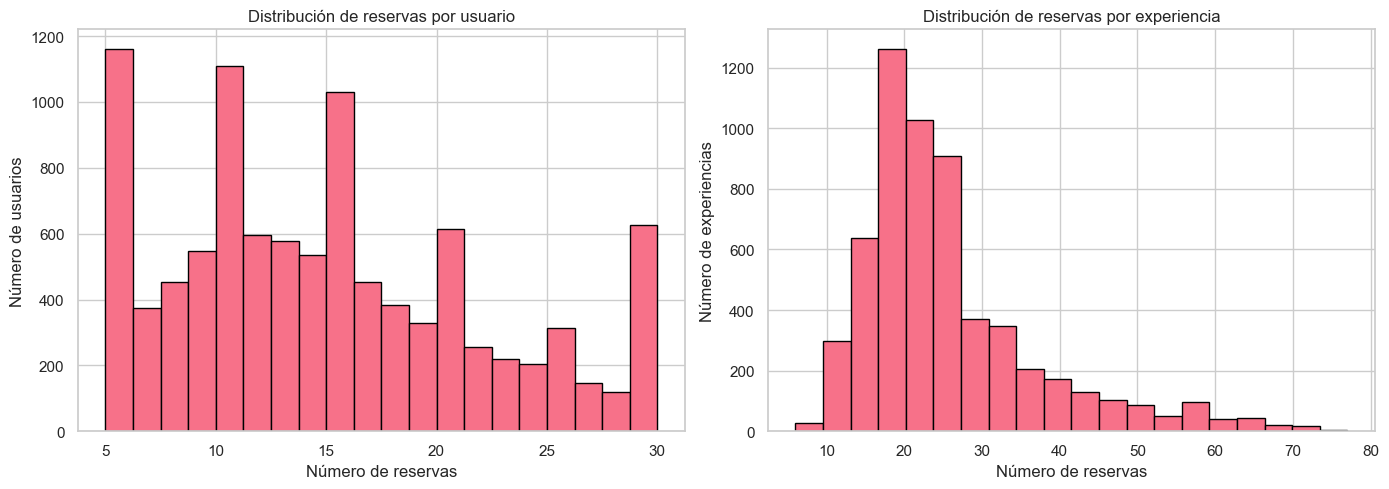

In [65]:
# Reservas por usuario
reservas_por_usuario = (
    df_bookings
    .groupby('customer_id')
    .size()
)

# Reservas por experiencia
reservas_por_experiencia = (
    df_bookings
    .groupby('experience_id')
    .size()
)

print('COMPORTAMIENTO DE USUARIOS Y EXPERIENCIAS')
print('=' * 60)

print('\n--- Reservas por usuario ---')
print(f'Media: {reservas_por_usuario.mean():.1f}')
print(f'Mediana: {reservas_por_usuario.median():.0f}')
print(f'Mínimo: {reservas_por_usuario.min()}')
print(f'Máximo: {reservas_por_usuario.max()}')

print('\n--- Reservas por experiencia ---')
print(f'Media: {reservas_por_experiencia.mean():.1f}')
print(f'Mediana: {reservas_por_experiencia.median():.0f}')
print(f'Mínimo: {reservas_por_experiencia.min()}')
print(f'Máximo: {reservas_por_experiencia.max()}')


# Interacciones usuario-experiencia únicas
interacciones_unicas = (
    df_bookings[['customer_id', 'experience_id']]
    .drop_duplicates()
)

n_usuarios = df_bookings['customer_id'].nunique()
n_experiencias = df_experiencias['experience_id'].nunique()

total_posibles = n_usuarios * n_experiencias

sparsity = (
    1 - len(interacciones_unicas) / total_posibles
) * 100

print('\n--- Matriz usuario-experiencia ---')
print(f'Interacciones únicas: {len(interacciones_unicas):,}')
print(f'Posibles combinaciones: {total_posibles:,}')
print(f'Sparsity: {sparsity:.2f}%')


# Usuarios que repiten una misma experiencia
repeticiones = df_bookings.duplicated(
    subset=['customer_id', 'experience_id']
).sum()

print(
    f'\nReservas repetidas usuario-experiencia: '
    f'{repeticiones:,}'
)


# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    reservas_por_usuario,
    bins=20,
    edgecolor='black'
)

axes[0].set_title('Distribución de reservas por usuario')
axes[0].set_xlabel('Número de reservas')
axes[0].set_ylabel('Número de usuarios')


axes[1].hist(
    reservas_por_experiencia,
    bins=20,
    edgecolor='black'
)

axes[1].set_title('Distribución de reservas por experiencia')
axes[1].set_xlabel('Número de reservas')
axes[1].set_ylabel('Número de experiencias')

plt.tight_layout()
plt.show()

Cada usuario tiene suficiente historial para analizar preferencias: la mediana es de 14 reservas por cliente. Las experiencias también tienen varias interacciones, con una mediana de 23 reservas por experiencia. La matriz usuario–experiencia es muy dispersa (99,75%), algo normal en sistemas de recomendación, porque cada usuario solo interactúa con una pequeña parte del catálogo. Por eso tiene sentido combinar el historial de reservas con atributos de las experiencias.

Y las 1.181 reservas repetidas usuario–experiencia no las eliminaría automáticamente: pueden indicar que un cliente ha reservado la misma experiencia más de una vez, lo que incluso puede ser una señal fuerte de afinidad.

### Distribución y concentración de la demanda por destino

Se analiza cómo se distribuyen las reservas entre destinos para identificar posibles concentraciones de demanda y evaluar la necesidad de mecanismos de redistribución turística.

CONCENTRACIÓN DE LA DEMANDA POR DESTINO

Top 10 destinos por número de reservas:
                Reservas  Porcentaje (%)  Acumulado (%)
destino_nombre                                         
Barcelona           8979            5.99           5.99
Mallorca            8172            5.45          11.44
Tenerife            7268            4.85          16.29
Ibiza               6374            4.25          20.54
Costa del Sol       5852            3.90          24.44
Madrid              5285            3.52          27.96
Gran Canaria        4798            3.20          31.16
Cancún              4561            3.04          34.21
Punta Cana          4478            2.99          37.19
Dubái               4286            2.86          40.05

Demanda concentrada en Top 5 destinos: 24.4%
Demanda concentrada en Top 10 destinos: 40.1%


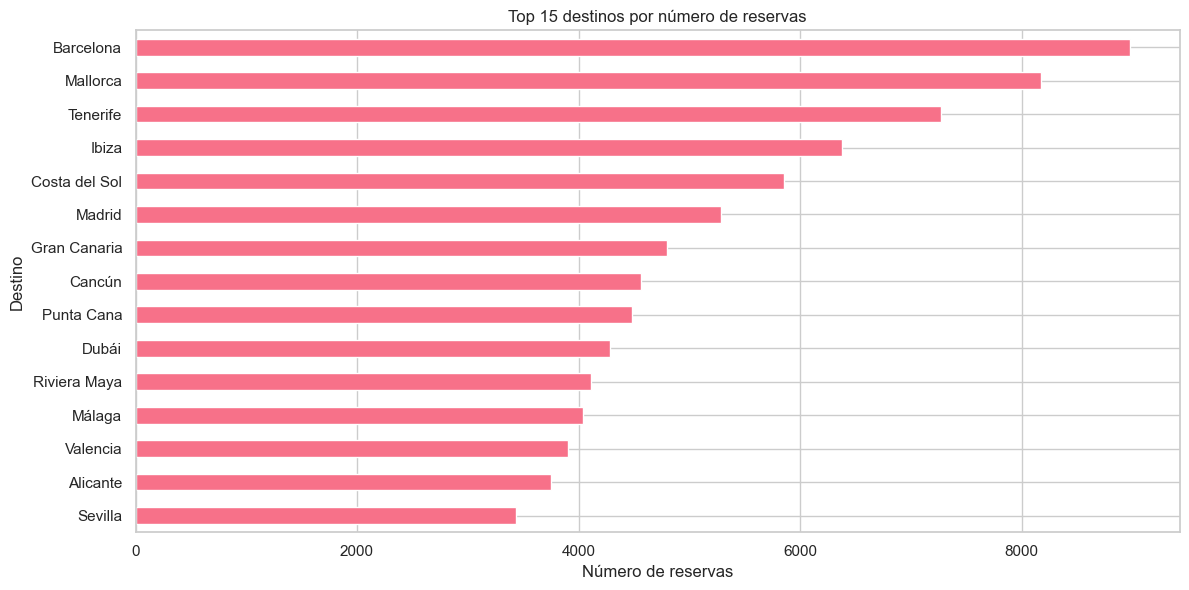

In [68]:
# Unir reservas con experiencias para conocer el destino de cada reserva
bookings_destino = df_bookings.merge(
    df_experiencias[['experience_id', 'destination']],
    on='experience_id',
    how='left'
)

# Renombrar para trabajar con un nombre más claro
bookings_destino = bookings_destino.rename(
    columns={'destination': 'destino_nombre'}
)

# Número de reservas por destino
reservas_destino = (
    bookings_destino
    .groupby('destino_nombre')
    .size()
    .sort_values(ascending=False)
)

# Porcentaje sobre el total
reservas_destino_pct = (
    reservas_destino / reservas_destino.sum() * 100
)

# Porcentaje acumulado
reservas_destino_acum = reservas_destino_pct.cumsum()

print('CONCENTRACIÓN DE LA DEMANDA POR DESTINO')
print('=' * 60)

print('\nTop 10 destinos por número de reservas:')

print(
    pd.DataFrame({
        'Reservas': reservas_destino,
        'Porcentaje (%)': reservas_destino_pct.round(2),
        'Acumulado (%)': reservas_destino_acum.round(2)
    }).head(10)
)

# Concentración Top 5 y Top 10
top5_pct = reservas_destino_pct.head(5).sum()
top10_pct = reservas_destino_pct.head(10).sum()

print(f'\nDemanda concentrada en Top 5 destinos: {top5_pct:.1f}%')
print(f'Demanda concentrada en Top 10 destinos: {top10_pct:.1f}%')

# Gráfico Top 15
top15 = reservas_destino.head(15)

fig, ax = plt.subplots(figsize=(12, 6))

top15.sort_values().plot(
    kind='barh',
    ax=ax
)

ax.set_title('Top 15 destinos por número de reservas')
ax.set_xlabel('Número de reservas')
ax.set_ylabel('Destino')

plt.tight_layout()
plt.show()

La demanda no está repartida de forma uniforme entre los destinos. Barcelona, Mallorca, Tenerife, Ibiza y Costa del Sol concentran conjuntamente el 24,4% de todas las reservas, mientras que los 10 destinos con más demanda acumulan el 40,1%. Esto muestra que existe cierta concentración territorial y justifica incorporar al recomendador un mecanismo que pueda proponer destinos alternativos compatibles con las preferencias del usuario.

**Conclusión:** La demanda presenta cierta concentración territorial. Los 5 destinos con más reservas acumulan el 24,4% del total y los 10 primeros el 40,1%. Esto justifica incorporar criterios de redistribución al sistema de recomendación, favoreciendo alternativas compatibles con las preferencias del usuario cuando exista una elevada presión sobre determinados destinos.

### Evolución temporal y estacionalidad de las reservas

Se analiza la distribución temporal de las reservas para identificar meses de mayor presión turística y comprobar si existen patrones estacionales relevantes para la redistribución de la demanda.

ESTACIONALIDAD DE LAS RESERVAS
Mes  Reservas  Porcentaje (%)
Ene     11071            7.38
Feb     10570            7.05
Mar     12417            8.28
Abr     12467            8.31
May     13521            9.02
Jun     13813            9.21
Jul     14533            9.69
Ago     13637            9.09
Sep     12612            8.41
Oct     12544            8.37
Nov     11499            7.67
Dic     11257            7.51

Mes con mayor demanda: Jul (14,533 reservas)
Mes con menor demanda: Feb (10,570 reservas)


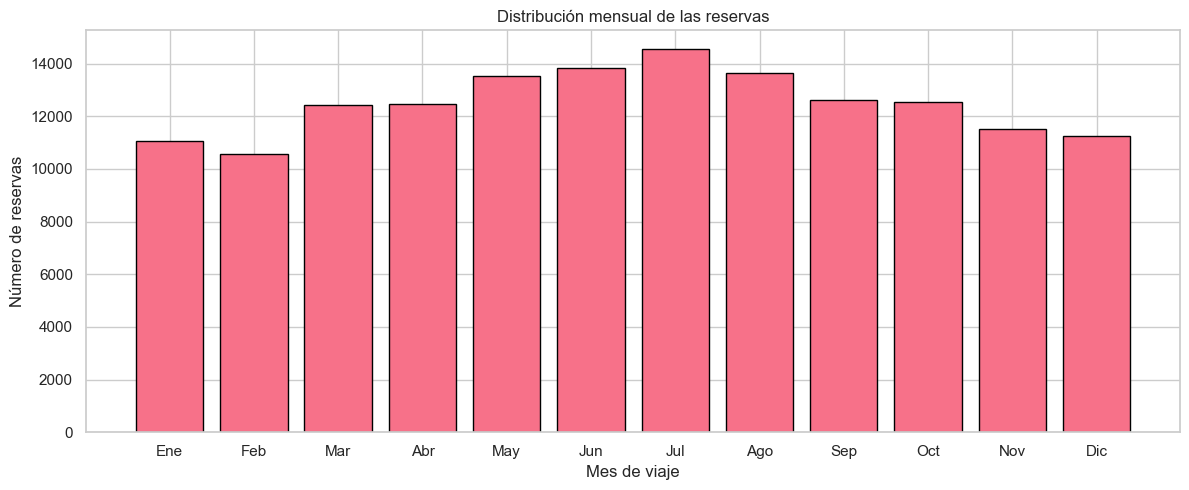

In [70]:
# Convertir fecha de viaje a formato fecha
df_bookings['travel_date'] = pd.to_datetime(
    df_bookings['travel_date'],
    errors='coerce'
)

# Crear variables temporales
df_bookings['anio_viaje'] = df_bookings['travel_date'].dt.year
df_bookings['mes_viaje'] = df_bookings['travel_date'].dt.month

# Número de reservas por mes
reservas_mes = (
    df_bookings
    .groupby('mes_viaje')
    .size()
    .reindex(range(1, 13))
)

nombres_meses = [
    'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
    'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'
]

print('ESTACIONALIDAD DE LAS RESERVAS')
print('=' * 60)

resumen_mensual = pd.DataFrame({
    'Mes': nombres_meses,
    'Reservas': reservas_mes.values
})

resumen_mensual['Porcentaje (%)'] = (
    resumen_mensual['Reservas']
    / resumen_mensual['Reservas'].sum()
    * 100
).round(2)

print(resumen_mensual.to_string(index=False))

# Meses con mayor y menor demanda
mes_max = resumen_mensual.loc[
    resumen_mensual['Reservas'].idxmax()
]

mes_min = resumen_mensual.loc[
    resumen_mensual['Reservas'].idxmin()
]

print(
    f'\nMes con mayor demanda: '
    f'{mes_max["Mes"]} ({mes_max["Reservas"]:,} reservas)'
)

print(
    f'Mes con menor demanda: '
    f'{mes_min["Mes"]} ({mes_min["Reservas"]:,} reservas)'
)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    resumen_mensual['Mes'],
    resumen_mensual['Reservas'],
    edgecolor='black'
)

ax.set_title('Distribución mensual de las reservas')
ax.set_xlabel('Mes de viaje')
ax.set_ylabel('Número de reservas')

plt.tight_layout()
plt.show()

sí existe estacionalidad, pero no es extrema: la demanda sube progresivamente hacia verano, alcanza su máximo en julio con 14.533 reservas (9,69%) y el mínimo está en febrero con 10.570 (7,05%).

**Conclusión:** La demanda presenta un patrón estacional moderado, con mayor concentración entre mayo y agosto y un máximo en julio. Aunque las reservas se mantienen relativamente repartidas durante todo el año, la estacionalidad debe tenerse en cuenta en el sistema de redistribución para evitar aumentar la presión turística en los meses de mayor demanda.

### Estacionalidad de la demanda por destino

Se analiza la distribución mensual de las reservas dentro de cada destino para identificar diferencias en sus patrones estacionales. Esto permite detectar destinos con mayor presión en determinados meses y posibles alternativas con una demanda más distribuida.

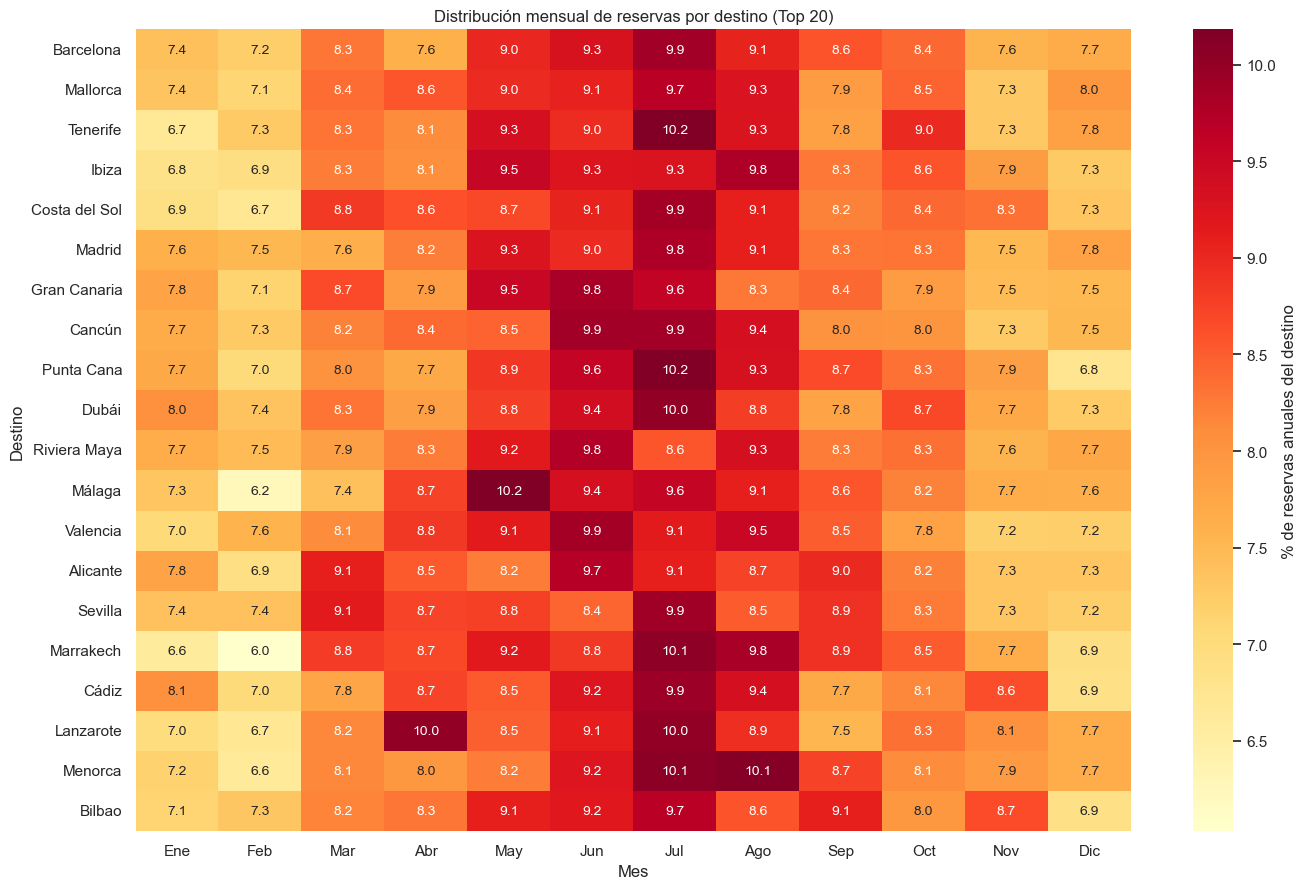

In [71]:
# Crear dataset con destino y mes de viaje
demanda_destino_mes = df_bookings.merge(
    df_experiencias[['experience_id', 'destination']],
    on='experience_id',
    how='left'
)

demanda_destino_mes['travel_date'] = pd.to_datetime(
    demanda_destino_mes['travel_date'],
    errors='coerce'
)

demanda_destino_mes['mes'] = (
    demanda_destino_mes['travel_date'].dt.month
)

# Reservas por destino y mes
tabla_destino_mes = pd.crosstab(
    demanda_destino_mes['destination'],
    demanda_destino_mes['mes']
)

# Asegurar los 12 meses
tabla_destino_mes = tabla_destino_mes.reindex(
    columns=range(1, 13),
    fill_value=0
)

tabla_destino_mes.columns = [
    'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
    'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'
]

# Normalizar dentro de cada destino
# Así analizamos estacionalidad y no simplemente popularidad
tabla_destino_mes_pct = (
    tabla_destino_mes
    .div(tabla_destino_mes.sum(axis=1), axis=0)
    * 100
)

# Ordenar por volumen total de reservas y mostrar Top 20
top_destinos = (
    tabla_destino_mes
    .sum(axis=1)
    .sort_values(ascending=False)
    .head(20)
    .index
)

heatmap_data = tabla_destino_mes_pct.loc[top_destinos]

# Gráfico
plt.figure(figsize=(14, 9))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    cbar_kws={'label': '% de reservas anuales del destino'}
)

plt.title('Distribución mensual de reservas por destino (Top 20)')
plt.xlabel('Mes')
plt.ylabel('Destino')

plt.tight_layout()
plt.show()

**Conclusión:** La estacionalidad varía entre destinos, aunque en general la demanda se concentra ligeramente entre mayo y agosto. Algunos destinos muestran picos más marcados, como Tenerife y Punta Cana en julio, Málaga en mayo, Gran Canaria en junio o Ibiza en agosto.



### Relación entre demanda y presión turística

Se cruza el volumen de reservas con el nivel de saturación conocido y la sensibilidad ambiental de cada destino. El objetivo es identificar destinos donde una demanda elevada pueda coincidir con una mayor presión turística o ambiental.

DEMANDA Y PRESIÓN TURÍSTICA

Top 15 destinos por reservas:
destino_nombre_reservas  reservas nivel_saturacion_conocido  sensibilidad_ambiental
              Barcelona      8979                  muy_alto                     0.5
               Mallorca      8172                      alto                     0.6
               Tenerife      7268                      alto                     0.7
                  Ibiza      6374                  muy_alto                     0.7
          Costa del Sol      5852                      alto                     0.4
                 Madrid      5285                      alto                     0.3
           Gran Canaria      4798                      alto                     0.7
                 Cancún      4561                  muy_alto                     0.7
             Punta Cana      4478                      alto                     0.6
                  Dubái      4286                      alto                     0.3
           Rivier

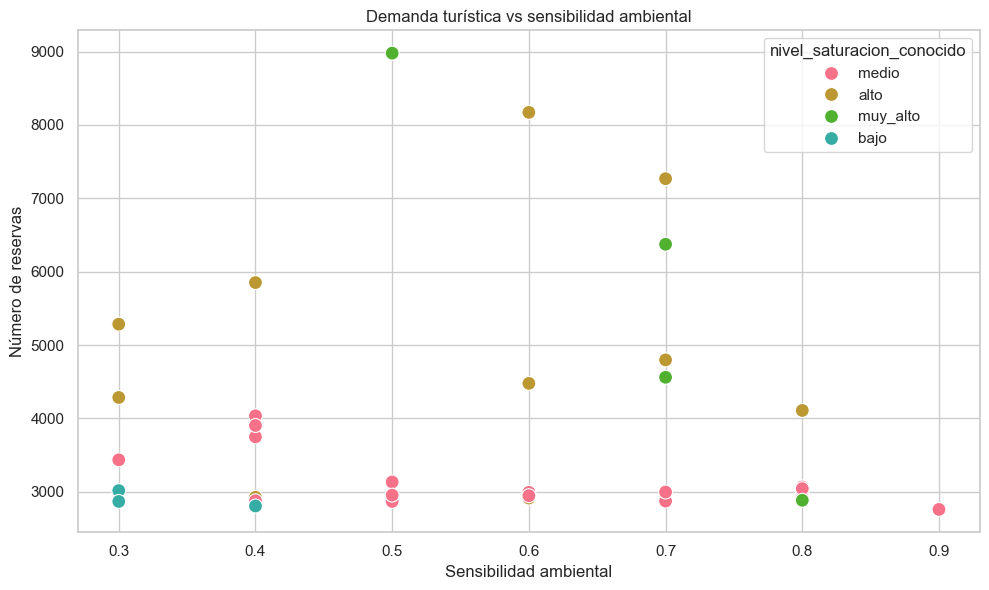

In [73]:
# ============================================================
# DEMANDA VS SATURACIÓN Y SENSIBILIDAD AMBIENTAL
# ============================================================

# Demanda total por destino
demanda_destino = (
    bookings_destino
    .groupby('destino_nombre')
    .size()
    .reset_index(name='reservas')
)

# Normalizar nombres para poder cruzar correctamente las fuentes
demanda_destino['destino_norm'] = (
    demanda_destino['destino_nombre']
    .apply(normalizar_destino)
)

df_destinos['destino_norm'] = (
    df_destinos['destino_nombre']
    .apply(normalizar_destino)
)

# Seleccionar variables relacionadas con sostenibilidad
sostenibilidad = df_destinos[
    [
        'destino_nombre',
        'destino_norm',
        'sensibilidad_ambiental',
        'nivel_saturacion_conocido'
    ]
].copy()

# Unir demanda con características del destino
demanda_sostenibilidad = demanda_destino.merge(
    sostenibilidad,
    on='destino_norm',
    how='left',
    suffixes=('_reservas', '_caracteristicas')
)

print('DEMANDA Y PRESIÓN TURÍSTICA')
print('=' * 60)

print('\nTop 15 destinos por reservas:')
print(
    demanda_sostenibilidad[
        [
            'destino_nombre_reservas',
            'reservas',
            'nivel_saturacion_conocido',
            'sensibilidad_ambiental'
        ]
    ]
    .sort_values('reservas', ascending=False)
    .head(15)
    .to_string(index=False)
)

# Promedio de reservas según nivel de saturación
reservas_saturacion = (
    demanda_sostenibilidad
    .groupby('nivel_saturacion_conocido')['reservas']
    .agg(['mean', 'median', 'count'])
    .round(1)
)

print('\n--- Reservas según nivel de saturación ---')
print(reservas_saturacion)


# Gráfico demanda vs sensibilidad ambiental
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=demanda_sostenibilidad,
    x='sensibilidad_ambiental',
    y='reservas',
    hue='nivel_saturacion_conocido',
    s=100
)

plt.title('Demanda turística vs sensibilidad ambiental')
plt.xlabel('Sensibilidad ambiental')
plt.ylabel('Número de reservas')

plt.tight_layout()
plt.show()

**Conclusión:** Los destinos con niveles de saturación altos y muy altos concentran, en promedio, un mayor volumen de reservas que los destinos con saturación media o baja. Además, algunos de los destinos más demandados presentan también una sensibilidad ambiental el motor de redistribución sostenible no debe basarse solo en la popularidad. Si un destino combina alta demanda, alta saturación y elevada sensibilidad ambiental, el sistema podrá reducir su prioridad y recomendar alternativas similares con menor presión turística.

### Revisión de la conectividad de los destinos

La conectividad es una variable relevante para valorar si un destino puede actuar como alternativa dentro del sistema de redistribución. Por ello, se comprueba la consistencia entre la conectividad almacenada en la base de datos y el CSV original.

In [74]:
# ============================================================
# REVISIÓN DE CONECTIVIDAD
# ============================================================

df_conectividad_db = query("SELECT * FROM conectividad_destinos")
df_conectividad_csv = pd.read_csv(CSV_CONECTIVIDAD)

print('REVISIÓN DE CONECTIVIDAD')
print('=' * 60)

# ------------------------------------------------------------
# 1. Problemas en la tabla integrada de la base de datos
# ------------------------------------------------------------

iata_vacio = (
    df_conectividad_db['iata_destino']
    .fillna('')
    .astype(str)
    .str.strip()
    .eq('')
)

pasajeros_cero = (
    df_conectividad_db['pasajeros_anuales']
    .fillna(0)
    .eq(0)
)

print(
    f'Destinos sin código IATA: '
    f'{iata_vacio.sum()} de {len(df_conectividad_db)}'
)

print(
    f'Destinos con 0 pasajeros anuales: '
    f'{pasajeros_cero.sum()} de {len(df_conectividad_db)}'
)


# ------------------------------------------------------------
# 2. Destinos que sí tienen correspondencia clara en el CSV
# ------------------------------------------------------------

mapeo_csv = {
    'Algarve': 'Algarve',
    'Antalya': 'Antalya',
    'Cancún': 'Cancún',
    'Cerdeña': 'Cerdeña',
    'Costa Amalfitana': 'Costa Amalfitana',
    'Creta': 'Creta',
    'Fuerteventura': 'Fuerteventura',
    'Gran Canaria': 'Gran Canaria',
    'Hurghada': 'Hurghada',
    'Lanzarote': 'Lanzarote',
    'Maldivas': 'Maldivas',
    'Marrakech': 'Marrakech',
    'Menorca': 'Menorca',
    'Punta Cana': 'Punta Cana',
    'Rodas': 'Rodas',
    'Santorini': 'Santorini',
    'Sicilia': 'Sicilia',
    'Split': 'Split'
}

df_conectividad_csv['termino_norm'] = (
    df_conectividad_csv['termino_original']
    .apply(normalizar_destino)
)

comparaciones = []

for destino, termino_csv in mapeo_csv.items():

    fila_db = df_conectividad_db[
        df_conectividad_db['destino_nombre'] == destino
    ]

    fila_csv = df_conectividad_csv[
        df_conectividad_csv['termino_norm']
        == normalizar_destino(termino_csv)
    ]

    if len(fila_db) > 0 and len(fila_csv) > 0:

        db = fila_db.iloc[0]
        csv = fila_csv.iloc[0]

        comparaciones.append({
            'destino': destino,
            'iata_db': db['iata_destino'],
            'iata_csv': csv['iata_destino'],
            'pasajeros_db': db['pasajeros_anuales'],
            'pasajeros_csv': csv['pasajeros_anuales_estimados']
        })


comparacion_conectividad = pd.DataFrame(comparaciones)

# Detectar discrepancias
discrepancias = comparacion_conectividad[
    (
        comparacion_conectividad['iata_db']
        .fillna('')
        .astype(str)
        .str.strip()
        !=
        comparacion_conectividad['iata_csv']
        .fillna('')
        .astype(str)
        .str.strip()
    )
    |
    (
        comparacion_conectividad['pasajeros_db']
        != comparacion_conectividad['pasajeros_csv']
    )
]

print('\n--- Discrepancias encontradas ---')

print(
    discrepancias.to_string(index=False)
)


# ------------------------------------------------------------
# 3. Casos que necesitan tratamiento específico
# ------------------------------------------------------------

print('\n--- Casos sin correspondencia única ---')
print(
    'Cabo Verde: existen varios aeropuertos en el CSV '
    '(Sal, Boa Vista, Santiago, etc.).'
)

print(
    'Túnez: no se ha encontrado una correspondencia directa '
    'en el CSV de conectividad.'
)

REVISIÓN DE CONECTIVIDAD
Destinos sin código IATA: 18 de 39
Destinos con 0 pasajeros anuales: 20 de 39

--- Discrepancias encontradas ---
         destino iata_db iata_csv  pasajeros_db  pasajeros_csv
         Algarve              FAO             0        1837836
         Antalya              AYT             0        1806012
          Cancún              CUN             0        1803360
         Cerdeña              CAG             0         564876
Costa Amalfitana              NAP             0        1400256
           Creta              HER             0        1630980
   Fuerteventura              FUE             0        2076516
    Gran Canaria     PMI      LPA       3763188        2522052
        Hurghada              HRG             0        1145664
       Lanzarote              ACE             0        2514096
        Maldivas     CMB      MLE        251940         251940
       Marrakech              RAK             0        1225224
         Menorca              MAH          

**Conclusión:** La conectividad almacenada en la base de datos presenta inconsistencias que deben corregirse antes de incorporarla al modelo. Varios destinos aparecen sin código IATA o con 0 pasajeros pese a disponer de datos en el CSV original, y se detectan asignaciones incorrectas como Gran Canaria y Maldivas.

 la conectividad influirá en la capacidad de un destino para actuar como alternativa dentro del sistema de redistribución. Si estos datos están mal mapeados, el modelo podría penalizar o favorecer destinos de forma incorrecta.
propuesta:
 - **Corregir el mapeo de conectividad** antes del modelado, tomando el CSV original como referencia para códigos IATA y pasajeros estimados. Los casos ambiguos, como Cabo Verde, deberán definirse mediante una regla específica.

### Calidad de las reseñas estructuradas

Se analiza la distribución de ratings, el sentimiento y la posible repetición de textos en `reviews_dataset`. Estas variables pueden utilizarse como señales de calidad y afinidad dentro del sistema de recomendación.

CALIDAD DE REVIEWS_DATASET
Total de reseñas: 52,172

--- Calidad básica ---
Valores nulos totales: 0
Duplicados exactos: 0
Textos repetidos: 16,900 (32.4%)
Textos únicos: 35,272

--- Distribución de ratings ---
1 estrellas: 3 (0.0%)
2 estrellas: 700 (1.3%)
3 estrellas: 9,247 (17.7%)
4 estrellas: 30,988 (59.4%)
5 estrellas: 11,234 (21.5%)

--- Sentiment score ---
Mínimo: 0.050
Media: 0.699
Mediana: 0.706
Máximo: 1.150
Valores de sentiment_score > 1: 4,679 (9.0%)
Correlación rating-sentimiento: 0.903


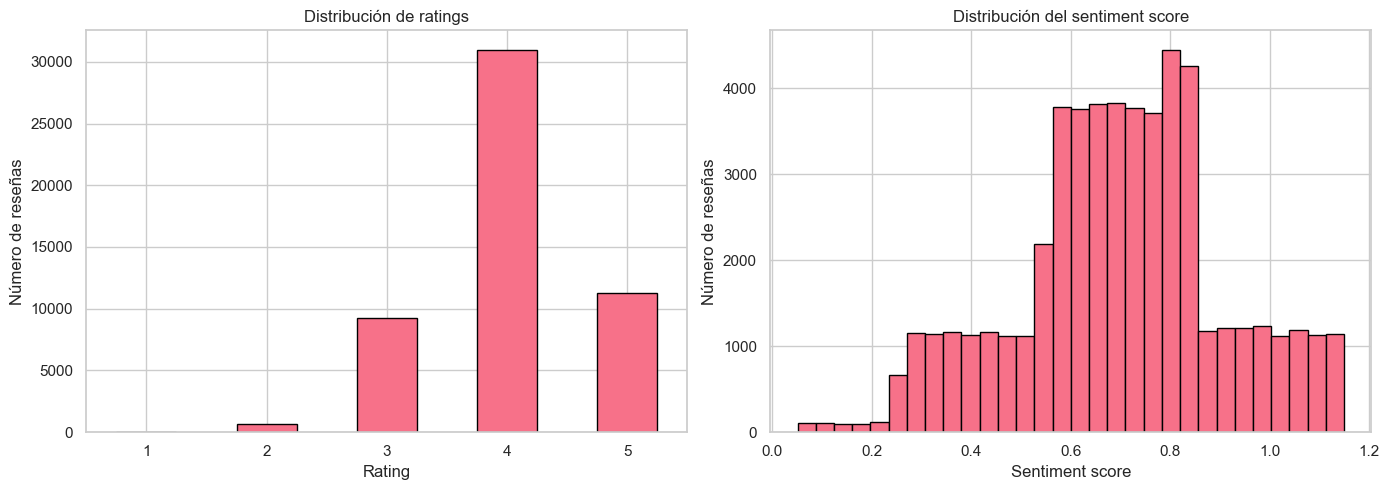

In [75]:
# ============================================================
# CALIDAD DE REVIEWS_DATASET
# ============================================================

print('CALIDAD DE REVIEWS_DATASET')
print('=' * 60)

print(f'Total de reseñas: {len(df_reviews):,}')

# ------------------------------------------------------------
# Nulos y duplicados
# ------------------------------------------------------------

print('\n--- Calidad básica ---')

print(f'Valores nulos totales: {df_reviews.isnull().sum().sum():,}')
print(f'Duplicados exactos: {df_reviews.duplicated().sum():,}')

textos_duplicados = df_reviews['review_text'].duplicated().sum()

print(
    f'Textos repetidos: {textos_duplicados:,} '
    f'({textos_duplicados / len(df_reviews) * 100:.1f}%)'
)

print(
    f'Textos únicos: {df_reviews["review_text"].nunique():,}'
)


# ------------------------------------------------------------
# Distribución de ratings
# ------------------------------------------------------------

rating_dist = (
    df_reviews['rating']
    .value_counts()
    .sort_index()
)

rating_pct = (
    df_reviews['rating']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print('\n--- Distribución de ratings ---')

for rating in rating_dist.index:
    print(
        f'{rating} estrellas: {rating_dist[rating]:,} '
        f'({rating_pct[rating]:.1f}%)'
    )


# ------------------------------------------------------------
# Sentimiento
# ------------------------------------------------------------

print('\n--- Sentiment score ---')

print(f'Mínimo: {df_reviews["sentiment_score"].min():.3f}')
print(f'Media: {df_reviews["sentiment_score"].mean():.3f}')
print(f'Mediana: {df_reviews["sentiment_score"].median():.3f}')
print(f'Máximo: {df_reviews["sentiment_score"].max():.3f}')

sentimiento_mayor_1 = (
    df_reviews['sentiment_score'] > 1
).sum()

print(
    f'Valores de sentiment_score > 1: '
    f'{sentimiento_mayor_1:,} '
    f'({sentimiento_mayor_1 / len(df_reviews) * 100:.1f}%)'
)

# Relación rating-sentimiento
corr_rating_sentiment = (
    df_reviews[['rating', 'sentiment_score']]
    .corr()
    .iloc[0, 1]
)

print(
    f'Correlación rating-sentimiento: '
    f'{corr_rating_sentiment:.3f}'
)


# ------------------------------------------------------------
# Visualización
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_dist.plot(
    kind='bar',
    ax=axes[0],
    edgecolor='black'
)

axes[0].set_title('Distribución de ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Número de reseñas')
axes[0].tick_params(axis='x', rotation=0)


axes[1].hist(
    df_reviews['sentiment_score'],
    bins=30,
    edgecolor='black'
)

axes[1].set_title('Distribución del sentiment score')
axes[1].set_xlabel('Sentiment score')
axes[1].set_ylabel('Número de reseñas')

plt.tight_layout()
plt.show()

El dataset está completo: no hay nulos ni duplicados exactos.
Pero 32,4% de los textos están repetidos, así que conviene tenerlo en cuenta antes de entrenar o generar embeddings.
Los ratings están muy concentrados en valores altos: casi el 81% son 4 o 5 estrellas, así que el rating tiene cierto sesgo positivo.
El sentiment_score también es bastante positivo y además hay un detalle importante: 9% de los valores superan 1, así que no podemos asumir que esté en escala [0,1].
Rating y sentimiento están muy relacionados: correlación 0,903, por lo que aportan señales parecidas.

**Conclusión:** Las reseñas estructuradas presentan buena calidad general, sin nulos ni duplicados exactos. Sin embargo, existe un 32,4% de textos repetidos y una fuerte concentración de ratings en 4 y 5 estrellas. Además, el `sentiment_score` supera el valor 1 en un 9% de los casos, por lo que será necesario revisar su escala antes del modelado.

EL rating, sentimiento y texto pueden utilizarse como señales de afinidad y calidad en el recomendador. Antes de incorporarlas al modelo debemos comprobar que no introduzcan sesgos o información redundante. Los textos repetidos se revisarán en preprocesamiento y el `sentiment_score` deberá normalizarse según su escala real antes de utilizarlo.

propuest: - **Revisar textos repetidos en `reviews_dataset`** antes de generar embeddings, evitando que contenidos duplicados tengan un peso excesivo.

- **Revisar la escala de `sentiment_score`**, ya que un 9% de los valores supera 1. No se normalizará hasta conocer cómo fue calculado.

- **Considerar el sesgo positivo del rating**, ya que la mayoría de las valoraciones se concentran en 4 y 5 estrellas.

---
## . DISTRIBUCIONES Y VARIABLES RELEVANTES

Analizamos las distribuciones de las variables mas importantes para el sistema de recomendacion.

### Distribucion de resenas por fuente e idioma

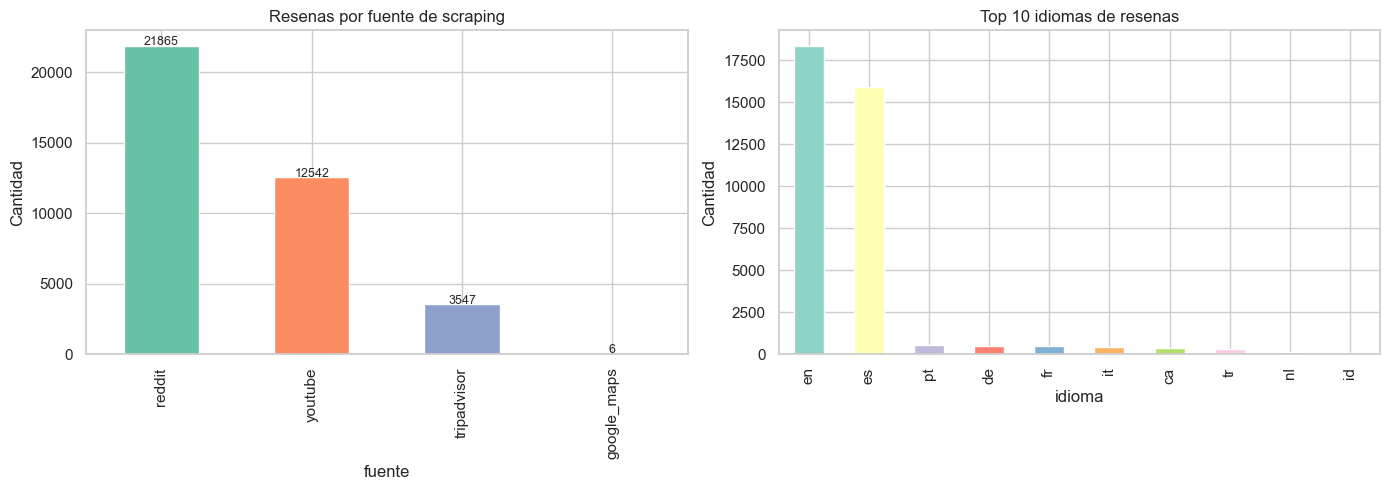

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por fuente
if 'fuente' in df_resenas.columns:
    fuente_counts = df_resenas['fuente'].value_counts()
    fuente_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(fuente_counts)))
    axes[0].set_title('Resenas por fuente de scraping')
    axes[0].set_ylabel('Cantidad')
    for i, v in enumerate(fuente_counts.values):
        axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)

# Por idioma
if 'idioma' in df_resenas.columns:
    idioma_counts = df_resenas['idioma'].value_counts().head(10)
    idioma_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('Set3', len(idioma_counts)))
    axes[1].set_title('Top 10 idiomas de resenas')
    axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

###  Distribucion de resenas por destino

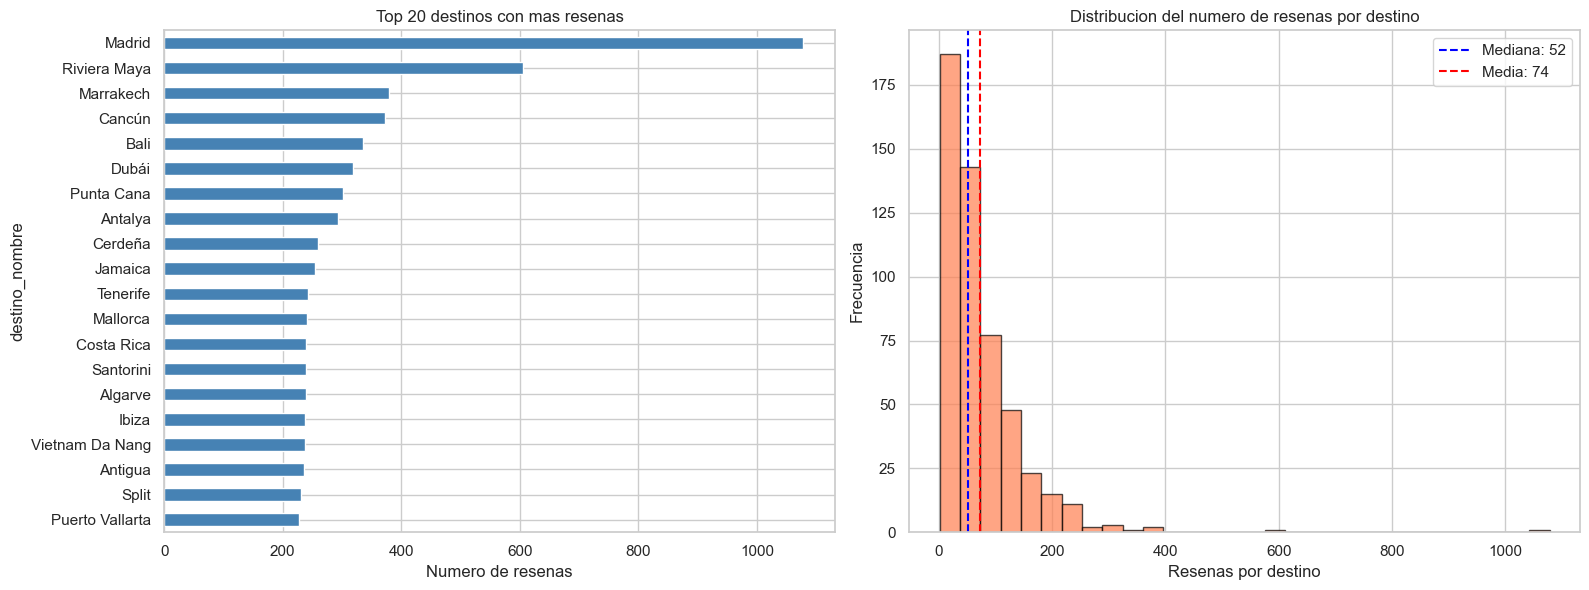


Estadisticas de resenas por destino:
  Media: 73.9
  Mediana: 52.0
  Desviacion estandar: 79.4
  Minimo: 2 (Granada)
  Maximo: 1078 (Madrid)

  PROPUESTA: Destinos con menos de 14 resenas (percentil 10) podrian requerir enriquecimiento adicional de datos.


In [50]:
if 'destino_nombre' in df_resenas.columns:
    dest_counts = df_resenas['destino_nombre'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Top 20 destinos
    dest_counts.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('Top 20 destinos con mas resenas')
    axes[0].set_xlabel('Numero de resenas')
    axes[0].invert_yaxis()
    
    # Distribucion (histograma del numero de resenas por destino)
    axes[1].hist(dest_counts.values, bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[1].axvline(dest_counts.median(), color='blue', linestyle='--', label=f'Mediana: {dest_counts.median():.0f}')
    axes[1].axvline(dest_counts.mean(), color='red', linestyle='--', label=f'Media: {dest_counts.mean():.0f}')
    axes[1].set_title('Distribucion del numero de resenas por destino')
    axes[1].set_xlabel('Resenas por destino')
    axes[1].set_ylabel('Frecuencia')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f'\nEstadisticas de resenas por destino:')
    print(f'  Media: {dest_counts.mean():.1f}')
    print(f'  Mediana: {dest_counts.median():.1f}')
    print(f'  Desviacion estandar: {dest_counts.std():.1f}')
    print(f'  Minimo: {dest_counts.min()} ({dest_counts.idxmin()})')
    print(f'  Maximo: {dest_counts.max()} ({dest_counts.idxmax()})')
    print(f'\n  PROPUESTA: Destinos con menos de {int(dest_counts.quantile(0.1))} resenas (percentil 10)'
          f' podrian requerir enriquecimiento adicional de datos.')

###  Longitud de textos de resenas

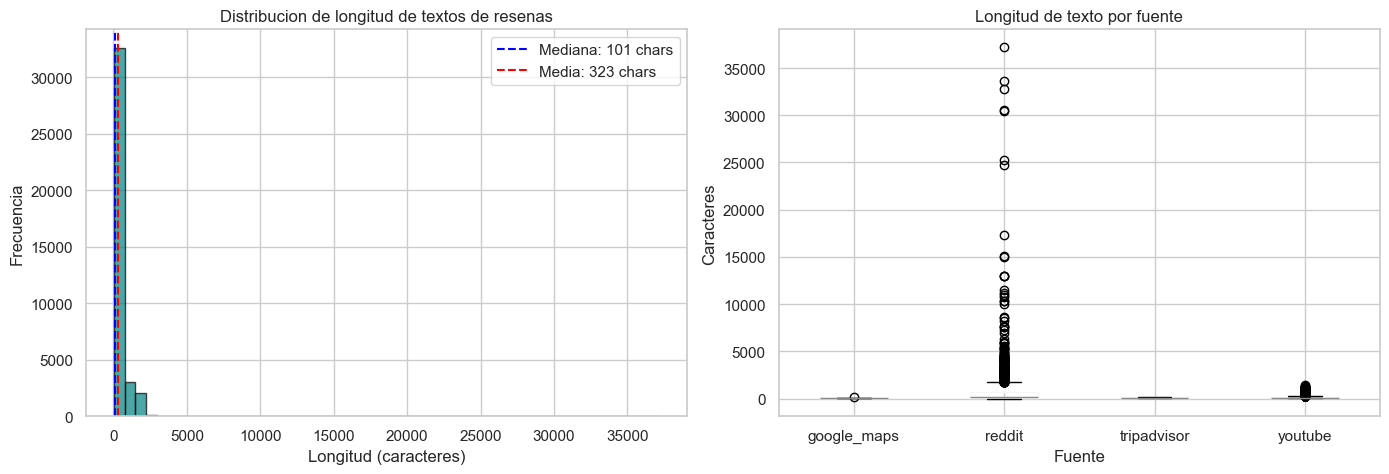


Textos con menos de 20 caracteres: 8 (0.0%)
PROPUESTA: Considerar excluir textos < 20 caracteres del calculo de embeddings.


In [51]:
if 'texto_original' in df_resenas.columns:
    df_resenas['len_texto'] = df_resenas['texto_original'].fillna('').str.len()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma de longitud
    axes[0].hist(df_resenas['len_texto'], bins=50, color='teal', edgecolor='black', alpha=0.7)
    axes[0].axvline(df_resenas['len_texto'].median(), color='blue', linestyle='--', 
                    label=f'Mediana: {df_resenas["len_texto"].median():.0f} chars')
    axes[0].axvline(df_resenas['len_texto'].mean(), color='red', linestyle='--', 
                    label=f'Media: {df_resenas["len_texto"].mean():.0f} chars')
    axes[0].set_title('Distribucion de longitud de textos de resenas')
    axes[0].set_xlabel('Longitud (caracteres)')
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()
    
    # Boxplot por fuente
    if 'fuente' in df_resenas.columns:
        df_resenas.boxplot(column='len_texto', by='fuente', ax=axes[1])
        axes[1].set_title('Longitud de texto por fuente')
        axes[1].set_xlabel('Fuente')
        axes[1].set_ylabel('Caracteres')
        plt.suptitle('')  # Eliminar titulo automatico
    
    plt.tight_layout()
    plt.show()
    
    # Textos muy cortos (potencialmente no utiles para embeddings)
    cortos = len(df_resenas[df_resenas['len_texto'] < 20])
    print(f'\nTextos con menos de 20 caracteres: {cortos} ({cortos/len(df_resenas)*100:.1f}%)')
    print(f'PROPUESTA: Considerar excluir textos < 20 caracteres del calculo de embeddings.')

###  Indicadores por fuente y tipo

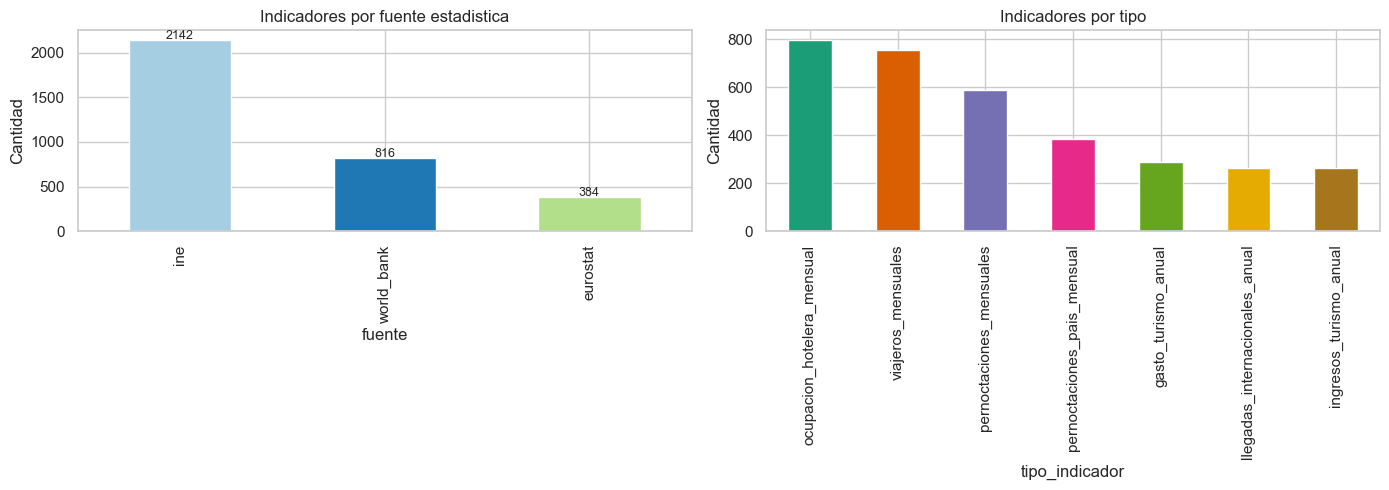

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'fuente' in df_indicadores.columns:
    fuente_ind = df_indicadores['fuente'].value_counts()
    fuente_ind.plot(kind='bar', ax=axes[0], color=sns.color_palette('Paired', len(fuente_ind)))
    axes[0].set_title('Indicadores por fuente estadistica')
    axes[0].set_ylabel('Cantidad')
    for i, v in enumerate(fuente_ind.values):
        axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

if 'tipo_indicador' in df_indicadores.columns:
    tipo_ind = df_indicadores['tipo_indicador'].value_counts()
    tipo_ind.plot(kind='bar', ax=axes[1], color=sns.color_palette('Dark2', len(tipo_ind)))
    axes[1].set_title('Indicadores por tipo')
    axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

### Datos climaticos

Estadisticas descriptivas - clima_todos_los_destinos.csv
       temp_media_aire_c  temp_media_agua_c  precipitacion_total_mm  \
count            1140.00             984.00                 1140.00   
mean               19.01              21.75                   75.66   
std                 7.20               5.39                   95.82   
min                -8.80               4.70                    0.00   
25%                13.80              17.70                   12.95   
50%                19.00              21.20                   44.55   
75%                24.80              26.20                  104.95   
max                36.90              34.70                 1105.90   

       dias_lluvia  horas_sol_totales  humedad_media_pct  
count      1140.00            1140.00            1140.00  
mean          8.78             308.06              69.87  
std           7.09              70.88              12.73  
min           0.00               4.90              14.10  
25%     

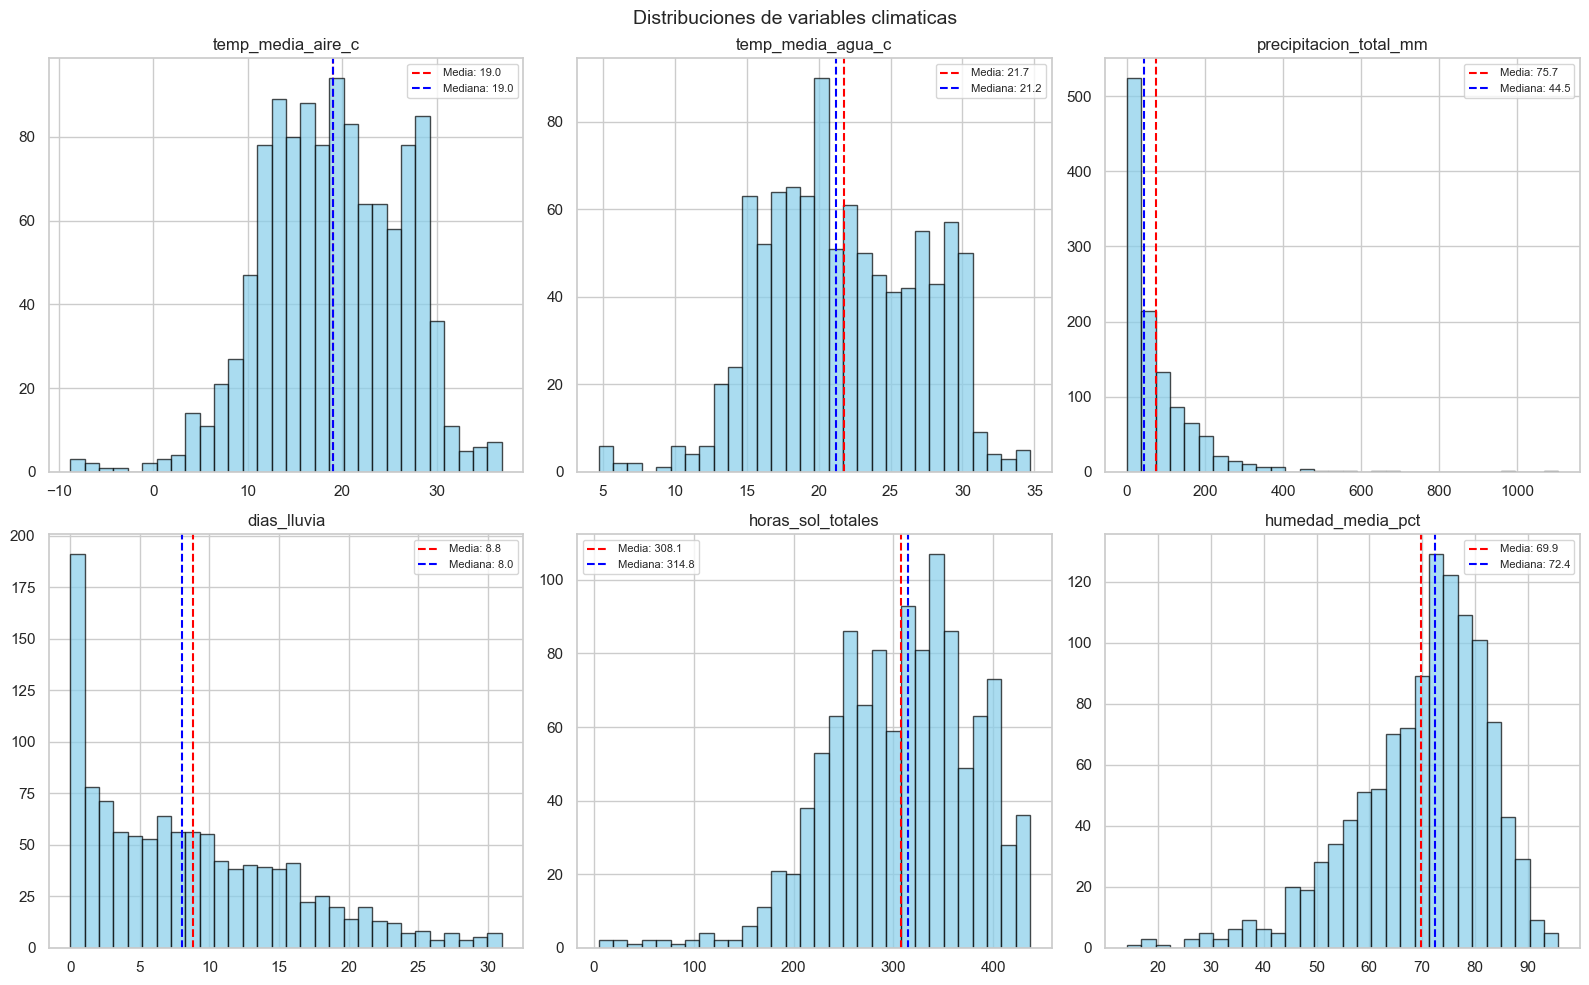

In [53]:
# Estadisticas descriptivas del CSV de clima
print('Estadisticas descriptivas - clima_todos_los_destinos.csv')
print('=' * 60)
# Seleccionar solo columnas numericas
numeric_cols = df_clima_csv.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    print(df_clima_csv[numeric_cols].describe().round(2))
    
    # Visualizacion de distribuciones
    n_cols = min(len(numeric_cols), 6)
    if n_cols > 0:
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes = axes.flatten()
        for i, col in enumerate(numeric_cols[:6]):
            axes[i].hist(df_clima_csv[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
            mean_val = df_clima_csv[col].mean()
            median_val = df_clima_csv[col].median()
            axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.1f}')
            axes[i].axvline(median_val, color='blue', linestyle='--', label=f'Mediana: {median_val:.1f}')
            axes[i].set_title(col)
            axes[i].legend(fontsize=8)
        # Ocultar ejes sobrantes
        for j in range(n_cols, 6):
            axes[j].set_visible(False)
        plt.suptitle('Distribuciones de variables climaticas', fontsize=14)
        plt.tight_layout()
        plt.show()

---
##  PATRONES, OUTLIERS Y RELACIONES ENTRE VARIABLES

### Deteccion de Outliers en resenas

Valores extremos en longitud de texto (método IQR):
  Límite superior IQR: 670 caracteres
  Textos por encima: 5,919 (15.6%)

Percentiles de longitud:
  Mediana (P50): 101 caracteres
  P90: 1061 caracteres
  P95: 1533 caracteres
  P99: 1659 caracteres
  Máximo: 37,228 caracteres

Textos muy largos:
  > 2.000 caracteres: 254 (0.67%)
  > 5.000 caracteres: 39 (0.10%)


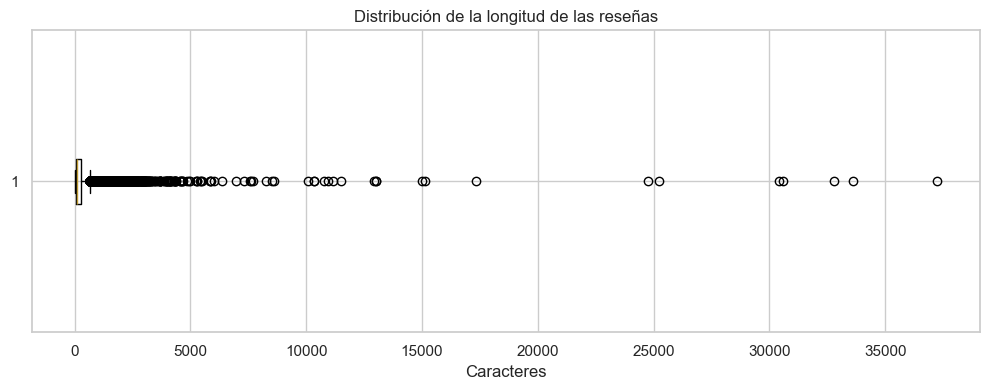


Conclusión:
Los textos detectados por IQR no se eliminarán automáticamente,
ya que una mayor longitud no implica menor calidad.
Solo los textos excepcionalmente largos se truncarán antes de generar embeddings.


In [61]:
if 'len_texto' in df_resenas.columns:

    # Método IQR: detectar textos con longitud atípica
    Q1 = df_resenas['len_texto'].quantile(0.25)
    Q3 = df_resenas['len_texto'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_resenas[
        (df_resenas['len_texto'] < lower) |
        (df_resenas['len_texto'] > upper)
    ]

    print('Valores extremos en longitud de texto (método IQR):')
    print(f'  Límite superior IQR: {upper:.0f} caracteres')
    print(f'  Textos por encima: {len(outliers):,} ({len(outliers)/len(df_resenas)*100:.1f}%)')

    # Percentiles para entender mejor la cola de la distribución
    print('\nPercentiles de longitud:')
    print(f'  Mediana (P50): {df_resenas["len_texto"].median():.0f} caracteres')
    print(f'  P90: {df_resenas["len_texto"].quantile(0.90):.0f} caracteres')
    print(f'  P95: {df_resenas["len_texto"].quantile(0.95):.0f} caracteres')
    print(f'  P99: {df_resenas["len_texto"].quantile(0.99):.0f} caracteres')
    print(f'  Máximo: {df_resenas["len_texto"].max():,.0f} caracteres')

    # Textos realmente muy largos
    mas_2000 = (df_resenas['len_texto'] > 2000).sum()
    mas_5000 = (df_resenas['len_texto'] > 5000).sum()

    print('\nTextos muy largos:')
    print(f'  > 2.000 caracteres: {mas_2000:,} ({mas_2000/len(df_resenas)*100:.2f}%)')
    print(f'  > 5.000 caracteres: {mas_5000:,} ({mas_5000/len(df_resenas)*100:.2f}%)')

    # Boxplot
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.boxplot(df_resenas['len_texto'].values, vert=False)

    ax.set_title('Distribución de la longitud de las reseñas')
    ax.set_xlabel('Caracteres')

    plt.tight_layout()
    plt.show()

    print('\nConclusión:')
    print('Los textos detectados por IQR no se eliminarán automáticamente,')
    print('ya que una mayor longitud no implica menor calidad.')
    print('Solo los textos excepcionalmente largos se truncarán antes de generar embeddings.')

El IQR marca 5.919 textos como largos, pero eso no significa que sean malos. De hecho, el 99% de las reseñas tiene menos de 1.659 caracteres y solo 254 textos (0,67%) superan los 2.000 caracteres. Por eso, mantener un límite de 2.000 caracteres es razonable: conserva prácticamente todo el contenido y solo recorta los casos realmente extremos.
entonces:
Truncar textos a 2.000 caracteres antes de generar embeddings, afectando únicamente al 0,67% de las reseñas.

### Outliers en indicadores de destino

In [62]:
if 'valor' in df_indicadores.columns and 'tipo_indicador' in df_indicadores.columns:

    resultados_outliers = []

    # Detectar valores atípicos dentro de cada destino,
    # no comparando directamente destinos de escalas diferentes
    for (tipo, destino), grupo in df_indicadores.groupby(
        ['tipo_indicador', 'destino_nombre']
    ):

        valores = grupo['valor'].dropna()

        # Se exige un mínimo de observaciones para que el IQR tenga sentido
        if len(valores) >= 8:

            q1 = valores.quantile(0.25)
            q3 = valores.quantile(0.75)
            iqr = q3 - q1

            limite_inf = q1 - 1.5 * iqr
            limite_sup = q3 + 1.5 * iqr

            n_outliers = (
                (valores < limite_inf) |
                (valores > limite_sup)
            ).sum()

            if n_outliers > 0:
                resultados_outliers.append({
                    'tipo_indicador': tipo,
                    'destino': destino,
                    'n_outliers': n_outliers
                })


    df_outliers_ind = pd.DataFrame(resultados_outliers)

    print('Valores atípicos detectados dentro de cada destino:')
    print('=' * 60)

    if len(df_outliers_ind) > 0:

        resumen = (
            df_outliers_ind
            .groupby('tipo_indicador')['n_outliers']
            .sum()
            .sort_values(ascending=False)
        )

        print(resumen)

        print(
            f'\nTotal de valores atípicos detectados: '
            f'{df_outliers_ind["n_outliers"].sum()}'
        )

    else:
        print('No se detectaron valores atípicos.')


    print('\nConclusión:')
    print(
        'Los valores extremos no se eliminarán automáticamente. '
        'Se revisarán dentro de la serie temporal de cada destino '
        'para distinguir entre picos reales y posibles errores.'
    )

Valores atípicos detectados dentro de cada destino:
tipo_indicador
ingresos_turismo_anual            11
llegadas_internacionales_anual    11
gasto_turismo_anual                7
ocupacion_hotelera_mensual         3
pernoctaciones_mensuales           3
Name: n_outliers, dtype: int64

Total de valores atípicos detectados: 35

Conclusión:
Los valores extremos no se eliminarán automáticamente. Se revisarán dentro de la serie temporal de cada destino para distinguir entre picos reales y posibles errores.


Lo que hace ahora es mejor que la versión anterior porque analiza los outliers dentro de cada destino y cada indicador, en vez de comparar directamente destinos muy diferentes entre sí.

Por ejemplo, ahora compara:

Mallorca consigo misma a lo largo del tiempo
Madrid consigo misma a lo largo del tiempo
Barcelona consigo misma a lo largo del tiempo

y detecta si algún mes/año se sale mucho de su comportamiento habitual.

Además, deja una decisión metodológica correcta:

Los valores extremos no se eliminan automáticamente, porque pueden ser picos turísticos reales y no errores.

entonces

De 3.342 registros, solo se detectan 35 valores atípicos (masomenos1%) cuando comparamos cada destino consigo mismo. La mayoría están en indicadores anuales de turismo. No los eliminamos, porque pueden ser cambios reales y simplemente quedan señalados para revisión.


entonces
Conclusión: Se detectan 35 valores atípicos al analizar cada destino de forma individual. No se eliminarán automáticamente, ya que pueden representar variaciones reales de la actividad turística y no necesariamente errores

### Correlaciones entre variables climaticas

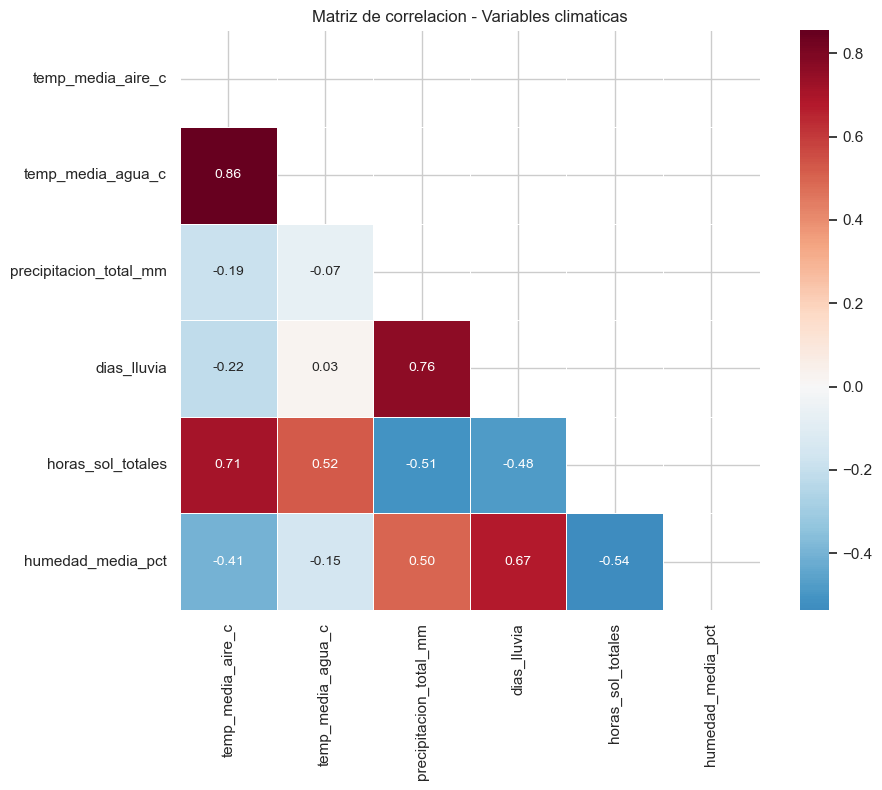

Correlaciones fuertes (|r| > 0.7):
  temp_media_aire_c <-> temp_media_agua_c: 0.855
  temp_media_aire_c <-> horas_sol_totales: 0.711
  precipitacion_total_mm <-> dias_lluvia: 0.757


In [56]:
numeric_cols_clima = df_clima_csv.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols_clima) >= 2:
    corr_matrix = df_clima_csv[numeric_cols_clima].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax, fmt='.2f')
    ax.set_title('Matriz de correlacion - Variables climaticas')
    plt.tight_layout()
    plt.show()
    
    # Correlaciones fuertes
    print('Correlaciones fuertes (|r| > 0.7):')
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            val = corr_matrix.iloc[i, j]
            if abs(val) > 0.7:
                print(f'  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {val:.3f}')

### Cobertura de destinos entre fuentes

In [57]:
import unicodedata
import re

# Destinos esperados en el proyecto
destinos_esperados = [
    'Mallorca', 'Tenerife', 'Ibiza', 'Costa del Sol', 'Barcelona',
    'Madrid', 'Malaga', 'Sevilla', 'Valencia', 'Gran Canaria',
    'Alicante', 'Bilbao', 'San Sebastian', 'Cordoba', 'Granada',
    'Cadiz', 'Fuerteventura', 'Lanzarote', 'Menorca', 'Antalya',
    'Rodas', 'Santorini', 'Hurghada', 'Punta Cana', 'Cancun',
    'Riviera Maya', 'Dubai', 'Maldivas', 'Bali', 'Phuket',
    'Marrakech', 'Cabo Verde', 'Split', 'Creta', 'Sicilia',
    'Cerdena', 'Costa Amalfitana', 'Algarve', 'Tunez'
]

# Normalizar nombres para evitar diferencias por tildes, mayusculas o espacios
def normalizar_destino(nombre):
    nombre = str(nombre).lower().strip()
    
    nombre = ''.join(
        c for c in unicodedata.normalize('NFKD', nombre)
        if not unicodedata.combining(c)
    )
    
    nombre = re.sub(r'\s+', ' ', nombre)
    
    return nombre


def check_coverage(df, col_name, dataset_name):
    
    destinos_data = set(
        df[col_name]
        .dropna()
        .apply(normalizar_destino)
    )
    
    presentes = [
        d for d in destinos_esperados
        if normalizar_destino(d) in destinos_data
    ]
    
    ausentes = [
        d for d in destinos_esperados
        if normalizar_destino(d) not in destinos_data
    ]
    
    return {
        'dataset': dataset_name,
        'presentes': len(presentes),
        'ausentes': len(ausentes),
        'total': len(destinos_esperados),
        'destinos_ausentes': ausentes
    }


coverages = [
    check_coverage(df_resenas, 'destino_nombre', 'resenas'),
    check_coverage(df_clima_db, 'destino_nombre', 'clima_destinos'),
    check_coverage(df_indicadores, 'destino_nombre', 'indicadores'),
    check_coverage(df_destinos, 'destino_nombre', 'destinos_caract')
]


print('COBERTURA DE DESTINOS ESPERADOS POR FUENTE')
print('=' * 60)

for c in coverages:
    
    pct = c['presentes'] / c['total'] * 100
    
    print(
        f"{c['dataset']:<25} "
        f"{c['presentes']}/{c['total']} "
        f"({pct:.1f}%)"
    )
    
    if c['ausentes'] > 0:
        print(
            f"    Ausentes: {', '.join(c['destinos_ausentes'])}"
        )

COBERTURA DE DESTINOS ESPERADOS POR FUENTE
resenas                   38/39 (97.4%)
    Ausentes: Sevilla
clima_destinos            39/39 (100.0%)
indicadores               39/39 (100.0%)
destinos_caract           39/39 (100.0%)


tras normalizar los nombres de los destinos, clima, indicadores y características presentan cobertura completa de los 39 destinos. La tabla de reseñas cubre 38 de los 39 destinos, siendo Sevilla el único sin coincidencia directa.

---
## VISUALIZACIONES Y PROPUESTAS DE TRATAMIENTO

### Comparativa Media vs Mediana por destino (resenas)

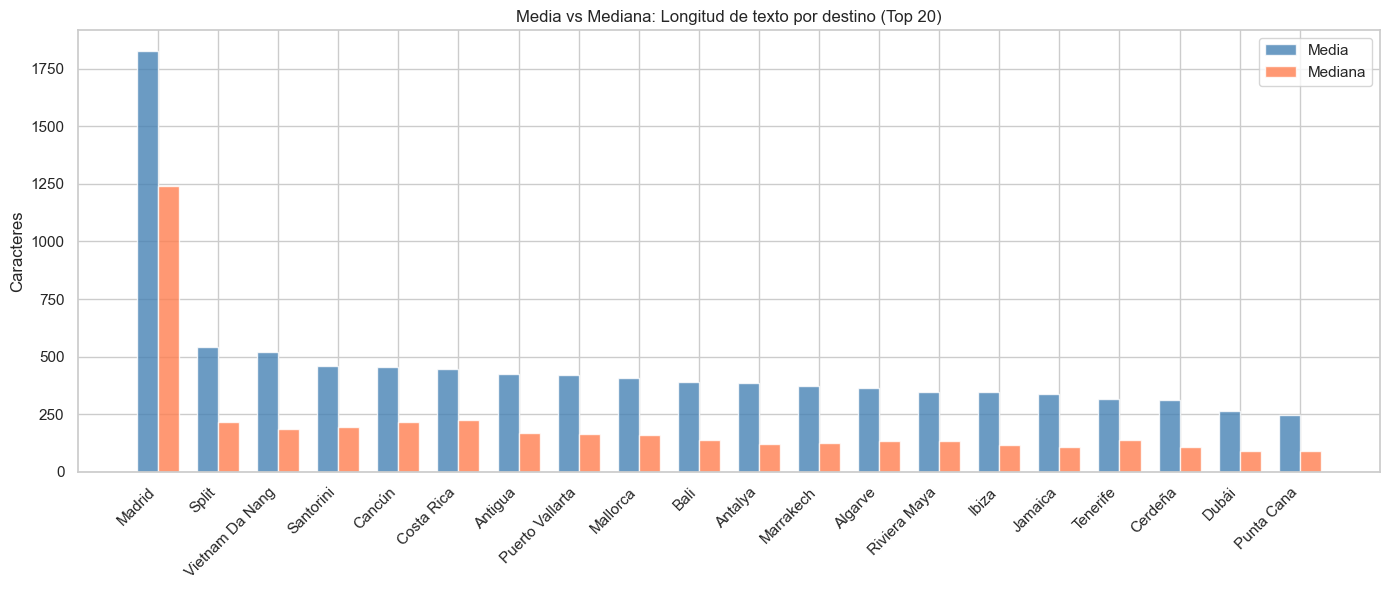

Destinos con alta diferencia Media-Mediana (sesgo positivo > 50%):
                  mean  median  diff_pct
destino_nombre                          
Split            542.0   218.0     148.6
Vietnam Da Nang  521.0   185.0     181.6
Santorini        460.0   196.0     134.7
Cancún           454.0   218.0     108.3
Costa Rica       447.0   224.0      99.6
Antigua          425.0   168.0     153.0
Puerto Vallarta  420.0   164.0     156.1
Mallorca         409.0   160.0     155.6
Bali             388.0   140.0     177.1
Antalya          384.0   123.0     212.2
Marrakech        372.0   126.0     195.2
Algarve          365.0   134.0     172.4
Riviera Maya     348.0   134.0     159.7
Ibiza            346.0   118.0     193.2
Jamaica          336.0   108.0     211.1
Tenerife         315.0   139.0     126.6
Cerdeña          310.0   107.0     189.7
Dubái            266.0    92.0     189.1
Punta Cana       246.0    92.0     167.4

Conclusión:
La diferencia entre media y mediana confirma que la longitu

In [63]:
if 'destino_nombre' in df_resenas.columns and 'len_texto' in df_resenas.columns:
    # Media y mediana de longitud de texto por destino (top 20)
    top_destinos = df_resenas['destino_nombre'].value_counts().head(20).index
    df_top = df_resenas[df_resenas['destino_nombre'].isin(top_destinos)]
    
    stats_destino = df_top.groupby('destino_nombre')['len_texto'].agg(['mean', 'median', 'std']).round(0)
    stats_destino = stats_destino.sort_values('mean', ascending=False)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    x = range(len(stats_destino))
    width = 0.35
    bars1 = ax.bar([i - width/2 for i in x], stats_destino['mean'], width, 
                   label='Media', color='steelblue', alpha=0.8)
    bars2 = ax.bar([i + width/2 for i in x], stats_destino['median'], width, 
                   label='Mediana', color='coral', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(stats_destino.index, rotation=45, ha='right')
    ax.set_title('Media vs Mediana: Longitud de texto por destino (Top 20)')
    ax.set_ylabel('Caracteres')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # Destinos con alta diferencia media-mediana (sesgo)
    stats_destino['diff_pct'] = ((stats_destino['mean'] - stats_destino['median']) / stats_destino['median'] * 100).round(1)
    sesgados = stats_destino[stats_destino['diff_pct'] > 50]
    if len(sesgados) > 0:
        print('Destinos con alta diferencia Media-Mediana (sesgo positivo > 50%):')
        print(sesgados[['mean', 'median', 'diff_pct']])

        print('\nConclusión:')
        print(
        'La diferencia entre media y mediana confirma que la longitud '
        'de las reseñas presenta una distribución sesgada.'
        )
        print(
        'Por ello, la mediana es más representativa que la media '
        'para describir la longitud típica de los textos.'
        )

En muchos destinos la media de longitud es bastante mayor que la mediana, lo que confirma que hay algunos textos muy largos que empujan la media hacia arriba. Por eso, para describir la longitud típica de las reseñas, la mediana es más representativa que la media.

### Propuestas para tratamiento de valores nulos

In [59]:
print('PROPUESTAS PARA TRATAMIENTO DE VALORES NULOS')
print('=' * 70)
print()
print('1. RESENAS:')
print('   - puntuacion (nula): NO imputar. Muchas fuentes (Reddit, YouTube)')
print('     no tienen puntuacion numerica. Usar solo para fuentes con rating.')
print('   - fecha_publicacion (nula): Imputar con fecha de extraccion si disponible.')
print('   - texto_original (vacio): EXCLUIR del calculo de embeddings.')
print()
print('2. INDICADORES DE DESTINO:')
print('   - mes (nulo): Correcto para indicadores anuales. No requiere imputacion.')
print('   - valor (negativo): Verificar si es error o valor valido segun tipo.')
print()
print('3. CLIMA:')
print('   - Variables con <5% nulos: Imputar con interpolacion temporal.')
print('   - Variables con >30% nulos: Evaluar exclusion de la variable.')
print()
print('4. CONECTIVIDAD/SEGURIDAD:')
print('   - Valores nulos por pais: Imputar con media regional si <20% nulos.')
print('   - Si >20% nulos en un pais: Excluir ese pais del analisis.')
print()
print('UMBRAL GENERAL (segun config.yml): Si un registro tiene >30% de atributos')
print('vacios, se excluye del sistema de recomendacion (parametro exclusion_threshold).')

PROPUESTAS PARA TRATAMIENTO DE VALORES NULOS

1. RESENAS:
   - puntuacion (nula): NO imputar. Muchas fuentes (Reddit, YouTube)
     no tienen puntuacion numerica. Usar solo para fuentes con rating.
   - fecha_publicacion (nula): Imputar con fecha de extraccion si disponible.
   - texto_original (vacio): EXCLUIR del calculo de embeddings.

2. INDICADORES DE DESTINO:
   - mes (nulo): Correcto para indicadores anuales. No requiere imputacion.
   - valor (negativo): Verificar si es error o valor valido segun tipo.

3. CLIMA:
   - Variables con <5% nulos: Imputar con interpolacion temporal.
   - Variables con >30% nulos: Evaluar exclusion de la variable.

4. CONECTIVIDAD/SEGURIDAD:
   - Valores nulos por pais: Imputar con media regional si <20% nulos.
   - Si >20% nulos en un pais: Excluir ese pais del analisis.

UMBRAL GENERAL (segun config.yml): Si un registro tiene >30% de atributos
vacios, se excluye del sistema de recomendacion (parametro exclusion_threshold).


### Resumen visual consolidado

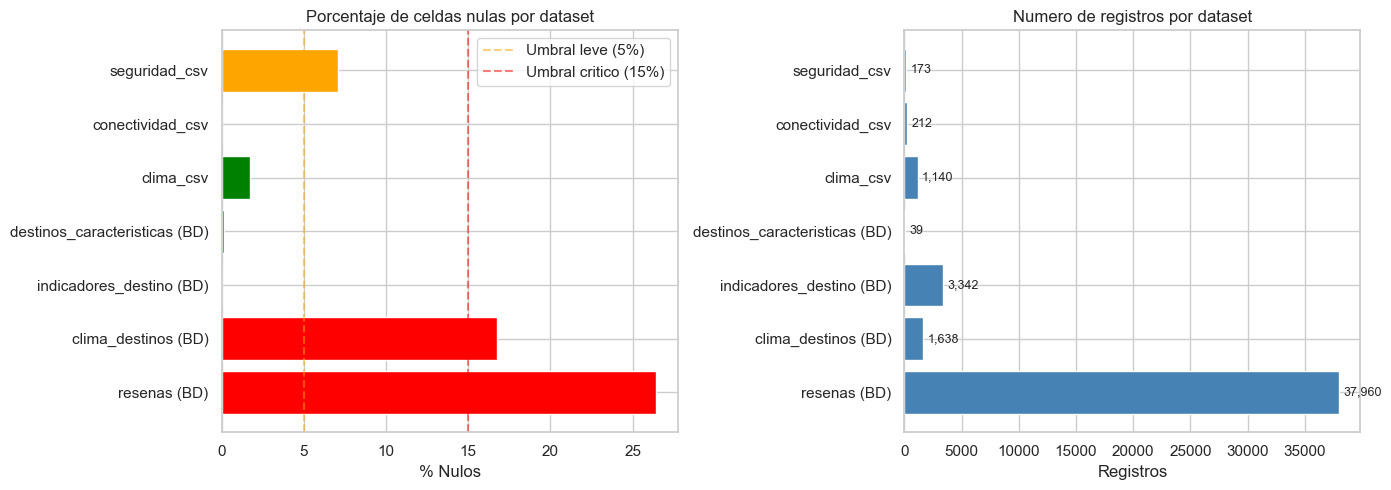

In [39]:
# Visualizacion consolidada de calidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Porcentaje de nulos por dataset
nombres = [r['Dataset'] for r in resumen_calidad]
pct_nulos = [r['% Nulos'] for r in resumen_calidad]
colors = ['green' if p < 5 else 'orange' if p < 15 else 'red' for p in pct_nulos]
axes[0].barh(nombres, pct_nulos, color=colors)
axes[0].axvline(x=5, color='orange', linestyle='--', alpha=0.5, label='Umbral leve (5%)')
axes[0].axvline(x=15, color='red', linestyle='--', alpha=0.5, label='Umbral critico (15%)')
axes[0].set_title('Porcentaje de celdas nulas por dataset')
axes[0].set_xlabel('% Nulos')
axes[0].legend()

# Grafico 2: Registros por dataset
registros = [r['Registros'] for r in resumen_calidad]
axes[1].barh(nombres, registros, color='steelblue')
axes[1].set_title('Numero de registros por dataset')
axes[1].set_xlabel('Registros')
for i, v in enumerate(registros):
    axes[1].text(v + max(registros)*0.01, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## CONCLUSIONES 

   - Puntuacion numerica ausente en fuentes sin rating (Reddit, YouTube)
   - Distribucion desigual de resenas por destino (sesgo hacia destinos populares)
   - Textos de longitud muy variable (algunos extremadamente largos)

**propuestas de tratamiento**
   - **NO imputar** puntuaciones: usar analisis de sentimiento del texto como proxy (Javie aqui estas tu)
   - **Truncar** textos a 2000 caracteres para embeddings 
   - **Excluir** registros con texto vacio del sistema de embeddings
   - **Usar mediana** como estadistico robusto para destinos con distribuciones sesgadas
   - **Enriquecer** datos para destinos con baja cobertura

Outliers**:
   - En longitud de texto: textos >5000 caracteres son posts completos. Truncar.
   - En indicadores: valores atipicos por cambios metodologicos entre anos. Verificar.


---
## CONCLUSIONES 14 agosto 2026

## Conclusiones del EDA y decisiones para preprocesamiento

El análisis exploratorio muestra que los datos disponibles son adecuados para construir un sistema de recomendación turística basado tanto en preferencias del usuario como en criterios de redistribución sostenible.

### Principales conclusiones

- Las tablas centrales del recomendador presentan buena integridad y están correctamente relacionadas.
- Los usuarios disponen de suficiente historial de reservas para analizar preferencias, aunque la matriz usuario–experiencia es muy dispersa, algo habitual en sistemas de recomendación.
- La demanda presenta cierta concentración territorial: los 5 destinos con más reservas acumulan el 24,4% del total y los 10 primeros el 40,1%.
- Existe una estacionalidad moderada, con mayor demanda entre mayo y agosto y un máximo en julio.
- Los destinos con niveles de saturación altos o muy altos presentan, en promedio, mayor demanda, y algunos combinan además una elevada sensibilidad ambiental.
- La cobertura general de destinos es completa en las principales fuentes, aunque algunos indicadores turísticos presentan cobertura desigual.
- Se han detectado inconsistencias en los datos de conectividad que deberán corregirse antes del modelado.
- Las reseñas presentan distribuciones de longitud muy sesgadas, aunque solo el 0,67% supera los 2.000 caracteres.
- En `reviews_dataset` existe un 32,4% de textos repetidos, los ratings están concentrados en valores altos y el `sentiment_score` requiere revisar su escala.

### Decisiones para la fase de preprocesamiento

- No imputar puntuaciones inexistentes en las reseñas externas.
- Excluir textos vacíos del cálculo de embeddings.
- Truncar textos excepcionalmente largos antes de generar embeddings, utilizando inicialmente 2.000 caracteres como referencia y ajustando posteriormente el límite al tokenizer del modelo.
- Revisar textos repetidos antes de generar embeddings para evitar una ponderación excesiva de contenidos duplicados.
- Revisar y normalizar la escala de `sentiment_score` antes de utilizarlo.
- Utilizar mediana y percentiles para describir variables numéricas fuertemente sesgadas cuando sea necesario.
- No eliminar automáticamente valores extremos de indicadores turísticos; deberán revisarse dentro de la serie temporal de cada destino.
- Mantener las fechas de publicación desconocidas como ausentes en lugar de sustituirlas por la fecha de extracción.
- Corregir el mapeo de conectividad tomando el CSV original como referencia antes de calcular variables asociadas a accesibilidad.
- Tener en cuenta la cobertura desigual de determinados indicadores antes de incorporarlos al modelo.

